In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spotify-dataset/dataset.csv


# EDA

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, KFold
from category_encoders import TargetEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Импорты для работы с данными
python
import pandas as pd
import numpy as np
pandas as pd: Это основная библиотека для работы с табличными данными. Она позволяет читать CSV-файлы (pd.read_csv), создавать DataFrame (таблицы), фильтровать данные, группировать их, создавать новые колонки и многое другое. Без pandas вы бы не смогли удобно работать с датасетом из 114,000 треков.

numpy as np: Библиотека для математических операций с числами и массивами. Она работает "под капотом" pandas и многих алгоритмов машинного обучения. Вы используете её для математических операций (например, np.sqrt для подсчета RMSE), создания диапазонов чисел (np.arange) и работы с массивами.

Импорты для визуализации
python
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.pyplot as plt: Это самая популярная библиотека для создания графиков в Python. Вы используете её для построения всех визуализаций в проекте: гистограмм, scatter-графиков, bar charts. Каждый раз, когда вы пишете plt.figure(), plt.bar(), plt.plot() — вы используете matplotlib.

seaborn as sns: Это надстройка над matplotlib, которая делает графики красивее и проще в создании. Она особенно хороша для статистических визуализаций. Вы используете её для тепловой карты корреляции (sns.heatmap), которая получилась очень наглядной.

Импорты для подготовки данных
python
from sklearn.model_selection import train_test_split, cross_validate, KFold
train_test_split: Эта функция делит ваши данные на обучающую и тестовую выборки. В проекте вы используете её дважды: сначала чтобы отделить тестовые данные (20%), а затем чтобы разделить оставшиеся данные на тренировочные и валидационные. Это критически важно для объективной оценки модели.

cross_validate и KFold: Эти инструменты нужны для кросс-валидации. Вместо того чтобы просто разделить данные один раз, KFold разбивает их на K частей (в вашем случае на 5), а cross_validate обучает модель K раз, каждый раз используя новую часть для проверки. Это дает более надежную оценку качества модели.

python
from category_encoders import TargetEncoder
Это специальная библиотека для кодирования категориальных признаков. В вашем проекте есть текстовые колонки: artists, album_name, track_name, track_genre, tags. TargetEncoder преобразует каждую уникальную категорию в число, равное среднему значению целевой переменной (popularity) для этой категории. Это очень умный способ превратить текст в числа, которые будут полезны для модели.

python
from sklearn.preprocessing import RobustScaler
Это инструмент для масштабирования числовых признаков. Он приводит все числа к одному масштабу, чтобы признаки с большими значениями (например, duration_min) не доминировали над признаками с маленькими значениями (например, danceability). RobustScaler использует медиану и квартили, что делает его устойчивым к выбросам (очень длинным трекам или аномально громким).

Импорты для моделей машинного обучения
Эти импорты нужны для создания и обучения самих моделей.

python
from sklearn.ensemble import RandomForestRegressor
Это модель "Случайный лес". Она состоит из множества деревьев решений и обычно дает хорошие результаты "из коробки". Вы используете её в основном для анализа важности признаков (feature_importances_), чтобы понять, какие факторы сильнее всего влияют на популярность.

python
from sklearn.linear_model import LinearRegression
Это самая простая модель — линейная регрессия. Она пытается описать зависимость популярности от других признаков как прямую линию (в многомерном пространстве). Она служит базовым уровнем (baseline) — если более сложные модели не превзойдут её, значит, они не нужны.

python
from sklearn.tree import DecisionTreeRegressor
Это модель "Дерево решений". Она работает как серия вопросов "да/нет" (например, "является ли трек синглом?" -> если да, то иди налево, если нет — направо). Вы используете её как промежуточную модель для сравнения.

python
from xgboost import XGBRegressor
Это одна из самых мощных и популярных моделей для табличных данных. XGBoost — это улучшенная версия градиентного бустинга. В вашем проекте эта модель показала наилучший результат.

Импорты для нейронной сети
python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
tensorflow.keras: Это высокоуровневая библиотека для создания нейронных сетей от Google.

Sequential: Это тип модели, где слои идут последовательно друг за другом (как слоеный пирог).

Dense: Это тип слоя, где каждый нейрон связан с каждым нейроном предыдущего слоя (полносвязный слой). Вы используете его для создания трех скрытых слоев (64, 32, 16 нейронов) и выходного слоя.

Импорты для метрик оценки
python
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
Эти функции нужны, чтобы понять, насколько хорошо работает модель.

r2_score: Коэффициент детерминации. Показывает, какую долю изменчивости популярности объясняет модель (от 0 до 1, где 1 — идеально).

mean_absolute_error (MAE): Средняя абсолютная ошибка. Говорит: "в среднем модель ошибается на X пунктов популярности".

mean_squared_error (MSE): Средняя квадратичная ошибка. Штрафует за большие ошибки сильнее, чем MAE.

mean_absolute_percentage_error (MAPE): Средняя абсолютная ошибка в процентах. Вы в итоге использовали SMAPE, но это тоже метрика для процентного выражения ошибки.

Резюме

In [73]:
df = pd.read_csv('/kaggle/input/spotify-dataset/dataset.csv')
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


Описание колонок:

* Unnamed: 0 - порядковый номер строки в датасете
* track_id - уникальный идентификатор трека в Spotify
* artists - список исполнителей трека
* album_name - название альбома
* track_name - название трека
* popularity - популярность трека
* duration_ms - длительность трека в миллисекундах
* explicit - наличие ненормативной лексики
* danceability - танцевальность трека (0 - не танцевальный, 1 - танцевальный)
* energy - энергичность трека (0 - спокойный, 1 - очень энергичный)
* key - тональность трека
* loudness - громкость трека в децибелах
* mode - лад трека (0 - минорный, 1 - мажорный)
* speechiness - наличие разговорной речи (0 - музыкальный, 1 разговорный)
* acousticness - акустичность трека (0- не акустический, 1 полностью акустический)
* instrumentalness - инструментальность трека (0 - вокальный, 1 инструментальный)
* liveness - наличие аудитории (0 студийная запись, 1 живое выступление)
* valence - позитивность трека (0 - грустный, 1 - позитивный)
* tempo - темп трека в ударах в минуту
* time_signature - музыкальный размер
* track_genre - музыкальный жанр трека

In [74]:
#Общая информация
print('Размеры датасета:')
print(df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())

Размеры датасета:
(114000, 21)

Типы данных:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Пропуски:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumental

In [ ]:
#Распределение треков по популярноcти
print(df['popularity'].value_counts().sort_index())
.value_counts() — это метод pandas, который подсчитывает, сколько раз встречается каждое уникальное значение в этом столбце.

Например, он считает: сколько треков имеют популярность 0, сколько треков имеют популярность 1, сколько треков имеют популярность 2, и так далее до 100.

.sort_index():

Сортирует результат по индексу (то есть по значению популярности) по возрастанию. Без этого сортировка могла бы быть по убыванию частоты.

popularity
0      16020
1       2140
2       1036
3        585
4        389
       ...  
96         7
97         8
98         7
99         1
100        2
Name: count, Length: 101, dtype: int64


**Определим наиболее популярных исполнителей**

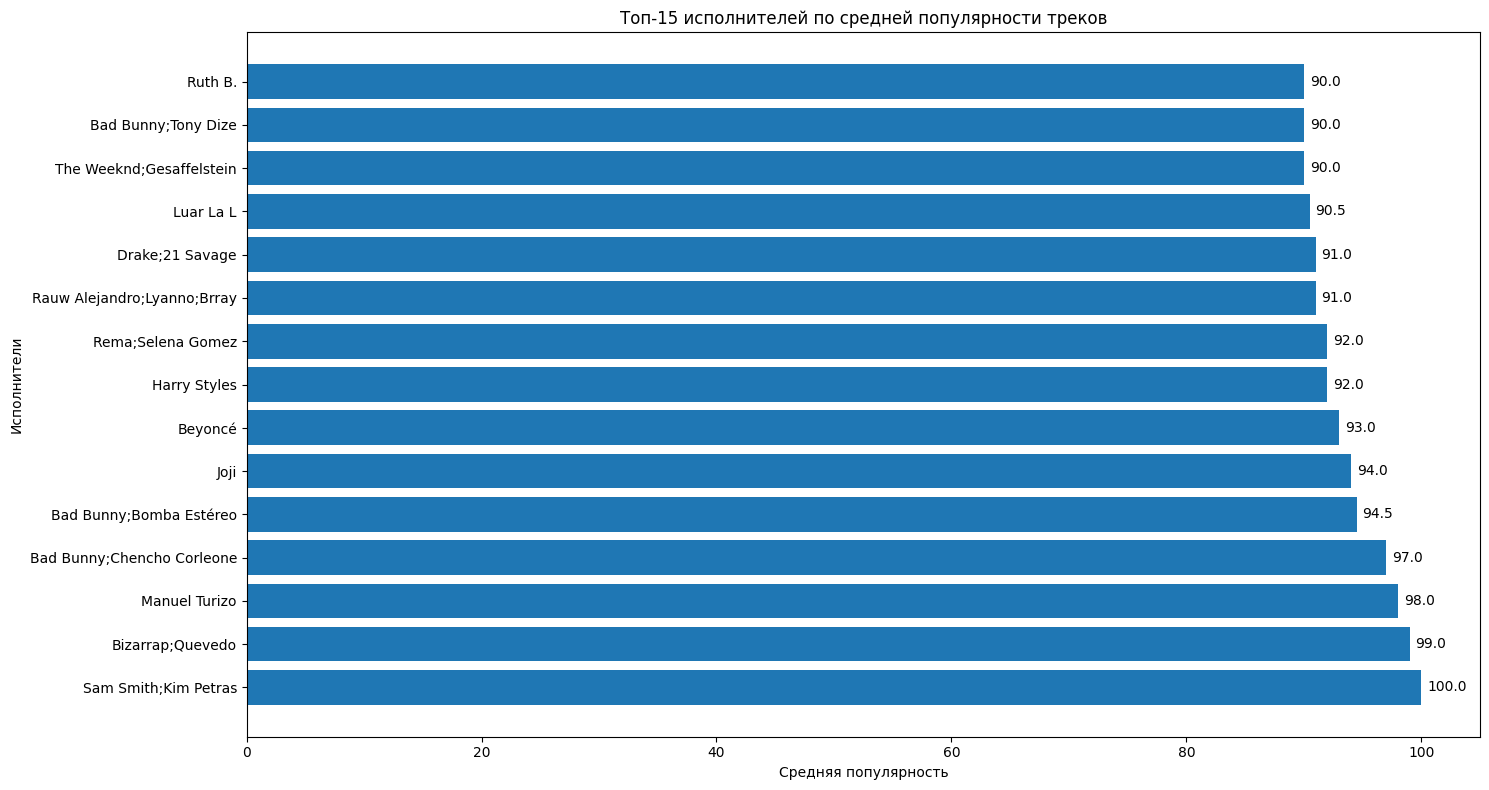

In [ ]:
# СОЗДАНИЕ СВОДНОЙ ТАБЛИЦЫ ПО ИСПОЛНИТЕЛЯМ
# -----------------------------------------------------------------
# groupby('artists') - группируем все строки датасета по исполнителям.
# Все треки одного исполнителя собираются в одну группу.
# agg() - выполняем агрегацию (объединение) данных внутри каждой группы.
#   mean_popularity - создаем новую колонку, где для каждого исполнителя
#                     считается СРЕДНЕЕ АРИФМЕТИЧЕСКОЕ популярности всех его треков.
#   track_count - создаем колонку с КОЛИЧЕСТВОМ треков этого исполнителя в датасете.
# sort_values() - сортируем полученную таблицу по убыванию средней популярности.
#                 Самые популярные исполнители оказываются наверху.
artist_popularity = df.groupby('artists').agg(
    mean_popularity=('popularity', 'mean'),
    track_count=('popularity', 'count'),
).sort_values('mean_popularity', ascending=False)

# ВЫБИРАЕМ ТОП-15 ИСПОЛНИТЕЛЕЙ
# -----------------------------------------------------------------
# head(15) - берем только первые 15 строк из отсортированной таблицы.
# Теперь в top_artists хранятся данные только о 15 самых популярных исполнителях.
top_artists = artist_popularity.head(15)

# СОЗДАЕМ ПОЛОТНО ДЛЯ ГРАФИКА
# -----------------------------------------------------------------
# figure() - создает новое пустое полотно для графика.
# figsize=(15, 8) - задает размер графика: 15 дюймов в ширину, 8 в высоту.
#                   Большой размер нужен, чтобы поместились длинные названия исполнителей.
plt.figure(figsize=(15, 8))

# СТРОИМ ГОРИЗОНТАЛЬНЫЕ СТОЛБЦЫ (BAR CHART)
# -----------------------------------------------------------------
# barh() - строит горизонтальный столбчатый график (bar horizontal).
#          Горизонтальный формат выбран, потому что названия исполнителей длинные,
#          и их удобнее читать слева, чем вертикально.
# top_artists.index - это названия исполнителей (индексы таблицы).
#                     Они станут подписями по вертикальной оси (Y).
# top_artists['mean_popularity'] - значения средней популярности.
#                                   Они определяют длину столбцов.
# bars = ... - сохраняем ссылку на построенные столбцы в переменную bars,
#              чтобы потом можно было с ними работать (например, подписывать значения).
bars = plt.barh(top_artists.index, top_artists['mean_popularity'])

# ДОБАВЛЯЕМ ЗАГОЛОВОК И ПОДПИСИ К ОСЯМ
# -----------------------------------------------------------------
plt.title('Топ-15 исполнителей по средней популярности треков')  # Заголовок графика
plt.xlabel('Средняя популярность')  # Подпись горизонтальной оси (X)
plt.ylabel('Исполнители')           # Подпись вертикальной оси (Y)

# ДОБАВЛЯЕМ ЧИСЛОВЫЕ ПОДПИСИ НА КАЖДЫЙ СТОЛБЕЦ
# -----------------------------------------------------------------
# Проходим в цикле по каждому построенному столбцу.
for bar in bars:
    # bar.get_width() - получаем длину текущего столбца (значение средней популярности).
    width = bar.get_width()
    
    # text(x, y, text) - рисует текст в указанных координатах.
    #   x = width + 0.5 - текст будет расположен чуть правее конца столбца (на 0.5 единицы),
    #                      чтобы не налезать на сам столбец.
    #   y = bar.get_y() + bar.get_height()/2 - вычисляем координату по Y, чтобы текст
    #                                            оказался ровно посередине столбца по высоте.
    #   f'{width:.1f}' - форматируем число с одним знаком после запятой (например, 94.3).
    #   ha='left' - горизонтальное выравнивание текста по левому краю (относительно точки x).
    #   va='center' - вертикальное выравнивание текста по центру.
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}', ha='left', va='center')

# ФИНАЛЬНАЯ НАСТРОЙКА И ОТОБРАЖЕНИЕ
# -----------------------------------------------------------------
# tight_layout() - автоматически подгоняет элементы графика,
#                  чтобы они не налезали друг на друга и все подписи поместились.
plt.tight_layout()
# show() - отображает готовый график на экране.
plt.show()

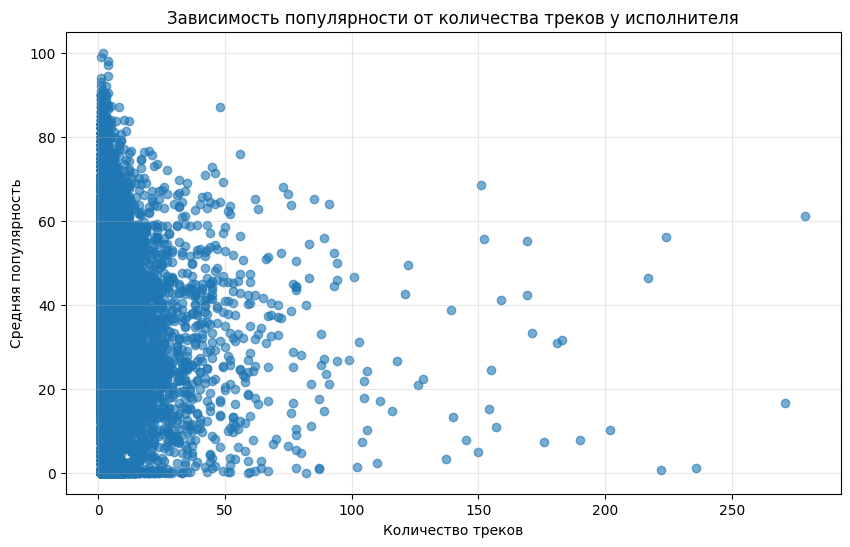

In [ ]:
# АНАЛИЗ СВЯЗИ КОЛИЧЕСТВА ТРЕКОВ И ПОПУЛЯРНОСТИ
# -----------------------------------------------------------------

# СОЗДАЕМ НОВОЕ ПОЛОТНО ДЛЯ ГРАФИКА
# -----------------------------------------------------------------
# figure() - создает новое пустое полотно для графика.
# figsize=(10, 6) - задает размер графика: 10 дюймов в ширину и 6 в высоту.
#                   Это стандартный, удобный для восприятия размер.
plt.figure(figsize=(10, 6))

# СТРОИМ ТОЧЕЧНУЮ ДИАГРАММУ (SCATTER PLOT)
# -----------------------------------------------------------------
# scatter() - создает точечную диаграмму (разброс точек).
#             Каждая точка на графике - это один исполнитель.
#
# artist_popularity['track_count'] - это данные для оси X (горизонтальной).
#                                     Здесь откладывается КОЛИЧЕСТВО треков у исполнителя.
#
# artist_popularity['mean_popularity'] - это данные для оси Y (вертикальной).
#                                         Здесь откладывается СРЕДНЯЯ популярность исполнителя.
#
# alpha=0.6 - делает точки полупрозрачными (прозрачность 60%).
#             Это нужно, чтобы в местах скопления множества точек
#             мы могли видеть плотность (чем больше точек наложилось,
#             тем темнее будет область).
plt.scatter(artist_popularity['track_count'], 
            artist_popularity['mean_popularity'], 
            alpha=0.6)

# ДОБАВЛЯЕМ ЗАГОЛОВОК И ПОДПИСИ К ОСЯМ
# -----------------------------------------------------------------
# title() - заголовок графика, объясняющий, что мы здесь анализируем.
plt.title('Зависимость популярности от количества треков у исполнителя')

# xlabel() - подпись горизонтальной оси (что отложено по X).
plt.xlabel('Количество треков')

# ylabel() - подпись вертикальной оси (что отложено по Y).
plt.ylabel('Средняя популярность')

# ДОБАВЛЯЕМ СЕТКУ ДЛЯ УДОБСТВА ЧТЕНИЯ
# -----------------------------------------------------------------
# grid(True) - включаем отображение сетки на графике.
# alpha=0.3 - делаем сетку бледной (прозрачность 30%), 
#             чтобы она не перекрывала основные данные.
plt.grid(True, alpha=0.3)

# ОТОБРАЖАЕМ ГОТОВЫЙ ГРАФИК
# -----------------------------------------------------------------
# show() - выводит готовый график на экран.
plt.show()

1. Отсутствие четкой закономерности
Главное, что бросается в глаза — точки разбросаны хаотично. Нет никакой четкой линии или тренда. Точки не выстраиваются ни в восходящую линию (чем больше треков, тем выше популярность), ни в нисходящую (чем больше треков, тем ниже популярность).
2. Анализ крайних случаев
Посмотрите на разные области графика:
Слева вверху (мало треков, высокая популярность): Есть исполнители, у которых всего 1-2 трека, но при этом очень высокая средняя популярность (близкая к 100). Это, скорее всего, исполнители-однохиты или недавно дебютировавшие артисты с вирусным треком.
Справа внизу (много треков, низкая популярность): Есть исполнители, у которых много треков (несколько десятков), но при этом очень низкая средняя популярность (близкая к 0). Это, вероятно, нишевые исполнители или исполнители с большой дискографией, но не попавшие в мейнстрим.
Основная масса: Большинство точек сконцентрировано в левой части графика (мало треков) и в нижней части (низкая популярность), что соответствует огромному количеству малоизвестных исполнителей.

**Вывод: анализ зависимости популярности от количества треков показывает отсутствие четкой корреляции. Точки на графике распределены хаотично без видимой закономерности. Исполнители с малым количеством треков могут иметь высокую популярность, а исполнители с большим количеством треков - низкую. Это свидетельствует о том, что количество треков не является определяющим фактором популярности исполнителя. Успех зависит от качества и востребованности конкретных композиций, а не от объема дискографии.**

**Гипотеза: инструментальные треки менее популярны чем вокальные**

Значение > 0.7 (больше 0.7) выбрано, чтобы взять треки с очень высокой уверенностью, что они инструментальные.
Значение <= 0.3 (меньше или равно 0.3) выбрано для треков с очень высокой уверенностью, что они вокальные.
<= 0.3 — это хороший компромисс: треки с низкой инструментальностью, т.е. с высокой вероятностью содержащие вокал.

Медианная популярность инструментальных треков: 25.0
Медианная популярность вокальных треков: 36.0


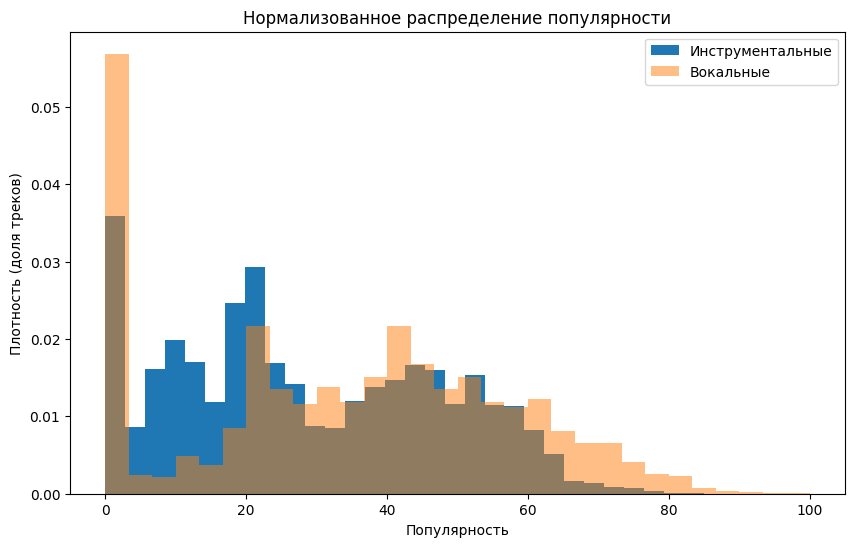

In [ ]:
# ПРОВЕРКА ГИПОТЕЗЫ: "Инструментальные треки менее популярны, чем вокальные"
# -----------------------------------------------------------------

# ВЫЧИСЛЯЕМ МЕДИАННУЮ ПОПУЛЯРНОСТЬ ДЛЯ ИНСТРУМЕНТАЛЬНЫХ ТРЕКОВ
# -----------------------------------------------------------------
# df[df['instrumentalness'] > 0.7] - фильтруем датасет:
#   оставляем только те строки, где instrumentalness (инструментальность) больше 0.7.
#   Это чисто инструментальные треки (без вокала).
# ['popularity'] - из отфильтрованных строк берем только столбец с популярностью.
# .median() - вычисляем МЕДИАНУ (значение, которое делиет выборку пополам)
#             популярности для этих инструментальных треков.
instrumental_median = df[df['instrumentalness'] > 0.7]['popularity'].median()

# ВЫЧИСЛЯЕМ МЕДИАННУЮ ПОПУЛЯРНОСТЬ ДЛЯ ВОКАЛЬНЫХ ТРЕКОВ
# -----------------------------------------------------------------
# df[df['instrumentalness'] <= 0.3] - фильтруем датасет:
#   оставляем только те строки, где instrumentalness меньше или равен 0.3.
#   Это треки с вокалом (инструментальность низкая).
# ['popularity'] - берем столбец популярности.
# .median() - вычисляем медиану популярности для вокальных треков.
vocal_median = df[df['instrumentalness'] <= 0.3]['popularity'].median()

# ВЫВОДИМ РЕЗУЛЬТАТЫ НА ЭКРАН
# -----------------------------------------------------------------
# print() - выводит текст и значения в консоль.
# f-строка (f'...') - форматированная строка, в которую можно подставлять значения переменных.
print(f'Медианная популярность инструментальных треков: {instrumental_median}')
print(f'Медианная популярность вокальных треков: {vocal_median}')

# СОЗДАЕМ ФИГУРУ И ОСИ ДЛЯ ГРАФИКА
# -----------------------------------------------------------------
# subplots() - создает фигуру (полотно) и набор осей для рисования.
# figsize=(10, 6) - задает размер графика: 10 дюймов в ширину, 6 в высоту.
# fig - это само полотно, ax - оси, на которых мы будем рисовать.
fig, ax = plt.subplots(figsize=(10, 6))

# СТРОИМ ГИСТОГРАММУ ДЛЯ ИНСТРУМЕНТАЛЬНЫХ ТРЕКОВ
# -----------------------------------------------------------------
# ax.hist() - строим гистограмму на осях ax.
# df[df['instrumentalness'] > 0.7]['popularity'] - данные для гистограммы:
#   берем популярность только инструментальных треков.
# bins=30 - разбиваем диапазон популярности на 30 корзин (интервалов).
# label='Инструментальные' - подпись для легенды (что эта гистограмма означает).
# density=True - НОРМАЛИЗУЕМ гистограмму. По оси Y теперь не количество треков,
#                а ПЛОТНОСТЬ ВЕРОЯТНОСТИ. Общая площадь под гистограммой = 1.
#                Это позволяет сравнивать распределения, даже если групп разного размера.
ax.hist(df[df['instrumentalness'] > 0.7]['popularity'], bins=30, 
        label='Инструментальные', density=True)

# СТРОИМ ГИСТОГРАММУ ДЛЯ ВОКАЛЬНЫХ ТРЕКОВ
# -----------------------------------------------------------------
# df[df['instrumentalness'] <= 0.3]['popularity'] - данные для гистограммы:
#   берем популярность только вокальных треков.
# alpha=0.5 - делаем гистограмму полупрозрачной (прозрачность 50%),
#             чтобы было видно, где они перекрываются.
# Остальные параметры те же: 30 корзин, нормализованная, подпись 'Вокальные'.
ax.hist(df[df['instrumentalness'] <= 0.3]['popularity'], bins=30, 
        alpha=0.5, label='Вокальные', density=True)

# НАСТРАИВАЕМ ПОДПИСИ И ЗАГОЛОВОК
# -----------------------------------------------------------------
# set_xlabel() - подпись горизонтальной оси (что отложено по X).
ax.set_xlabel('Популярность')

# set_ylabel() - подпись вертикальной оси. Здесь "Плотность (доля треков)",
#                 потому что мы использовали density=True.
ax.set_ylabel('Плотность (доля треков)')

# set_title() - заголовок графика.
ax.set_title('Нормализованное распределение популярности')

# ДОБАВЛЯЕМ ЛЕГЕНДУ (чтобы понять, где инструментальные, а где вокальные)
# -----------------------------------------------------------------
# legend() - отображает легенду на графике, используя подписи из label=...
ax.legend()

# ОТОБРАЖАЕМ ГОТОВЫЙ ГРАФИК
# -----------------------------------------------------------------
# show() - выводит график на экран.
plt.show()

Огромное количество треков с популярностью 0 (16 020 штук!)

Очень мало треков с высокой популярностью

Если бы мы взяли среднее арифметическое, эти 16 020 нулей просто "утопили" бы среднее значение. Даже если бы у нас было несколько супер-хитов с популярностью 100, среднее все равно было бы низким из-за огромного количества "шума".

**Вывод: гипотеза подтвердилась - инструментальные треки имеют значительно более низкую медианную популярность (25) по сравнению с вокальными треками (36). Нормализованная гистограмма показывает, что распределение популярности вокальных треков смещено вправо в сторону более высоких значений, в то время как у инструментальных треков преобладают низкие значения популярности, что подтверждает существенное влияние вокала на успех музыкальной композиции.**

**Гипотеза: танцевальные треки более популярны чем нетанцевальные**

Медианная популярность танцевальных треков: 34.0
Медианная популярность нетанцевальных треков: 24.0


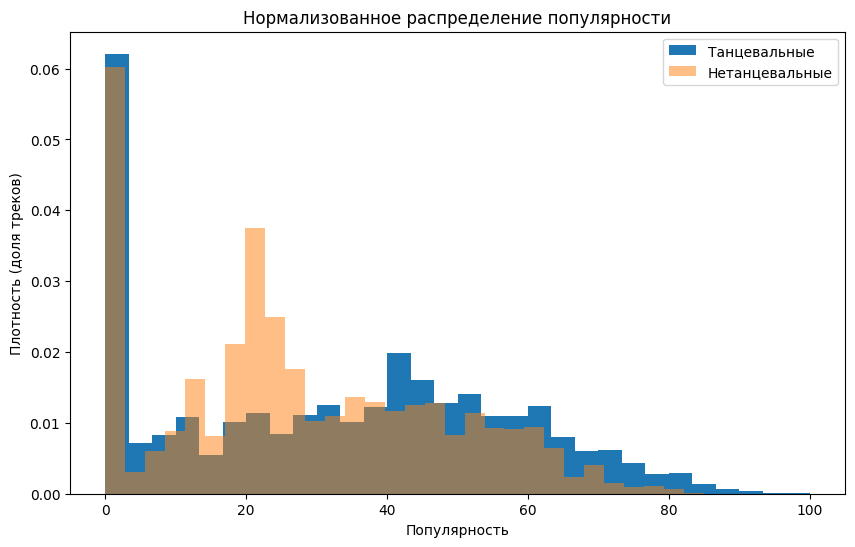

In [79]:
#Считаем медианную популярность для танцевальных треков (danceability > 0.7)
dance_median = df[df['danceability'] > 0.7]['popularity'].median()
#Считаем медианную популярность для нетанцевальных треков (danceability <= 0.3)
no_dance_median = df[df['danceability'] <= 0.3]['popularity'].median()

print(f'Медианная популярность танцевальных треков: {dance_median}')
print(f'Медианная популярность нетанцевальных треков: {no_dance_median}')

#Визуалиация нормализованных гистограмм (density=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[df['danceability'] > 0.7]['popularity'], bins=30, label='Танцевальные', density=True)
ax.hist(df[df['danceability'] <= 0.3]['popularity'], bins=30, alpha=0.5, label='Нетанцевальные', density=True)
ax.set_xlabel('Популярность')
ax.set_ylabel('Плотность (доля треков)')
ax.set_title('Нормализованное распределение популярности')
ax.legend()
plt.show()

**Вывод: гипотеза подтвердилась - танцевальные треки имеют более высокую медианную популярность (34) по сравнению с нетанцевальными треками (24). Нормализованная гистограмма показывает, что распределение популярности танцевальных треков смещено вправо в сторону более высоких значений, тогда как у нетанцевальных треков преобладают низкие значения популярности, что подтверждает важность танцевальности для успеха музыкальных композиций.**

**Гипотеза: электронные треки популярнее акустических**

Медианная популярность электронных треков: 34.0
Медианная популярность акустических треков: 28.0


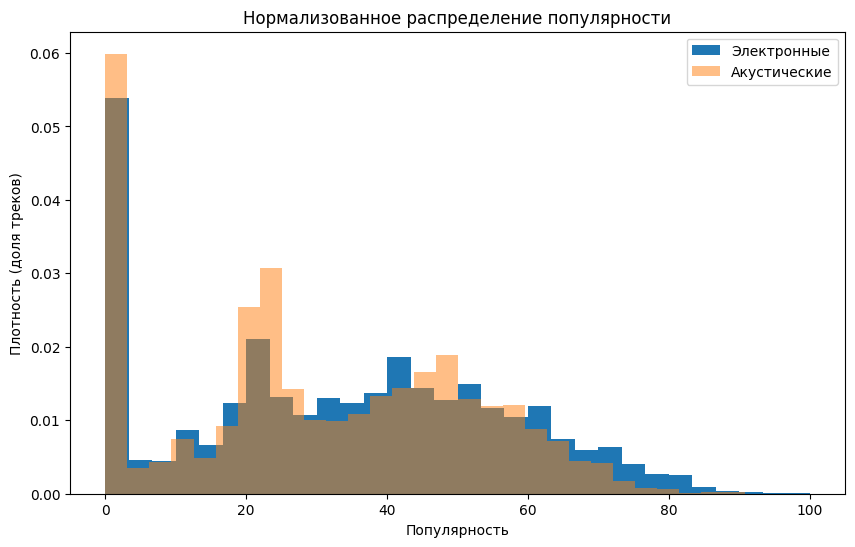

In [80]:
#Считаем медианную популярность для акустических треков (acousticness > 0.7)
acoustic_median = df[df['acousticness'] > 0.7]['popularity'].median()
#Считаем медианную популярность для электронных треков (acousticness <= 0.3)
electronic_median = df[df['acousticness'] <= 0.3]['popularity'].median()

print(f'Медианная популярность электронных треков: {electronic_median}')
print(f'Медианная популярность акустических треков: {acoustic_median}')

#Визуалиация нормализованных гистограмм
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[df['acousticness'] <= 0.3]['popularity'], bins=30, label='Электронные', density=True)
ax.hist(df[df['acousticness'] > 0.7]['popularity'], bins=30, alpha=0.5, label='Акустические', density=True)
ax.set_xlabel('Популярность')
ax.set_ylabel('Плотность (доля треков)')
ax.set_title('Нормализованное распределение популярности')
ax.legend()
plt.show()

**Вывод: гипотеза подтвердилась - электронные треки имеют более высокую медианную популярность (34) по сравнению с акустическими треками (28). Нормализованная гистограмма показывает, что распределение популярности электронных треков имеет более высокую плотность в области высоких значений популярности, в то время как у акустических треков преобладают низкие и средние значения. Это демонстрирует предпочтение слушателей электронному звучанию над акустическим.**

**Гипотеза: треки средней длительности (3-5 минут) наиболее популярны**

Медианная популярность треков 3-5 минут: 37.0
Медианная популярность треков короче 3 минут: 30.0
Медианная популярность треков длиннее 5 минут: 30.0


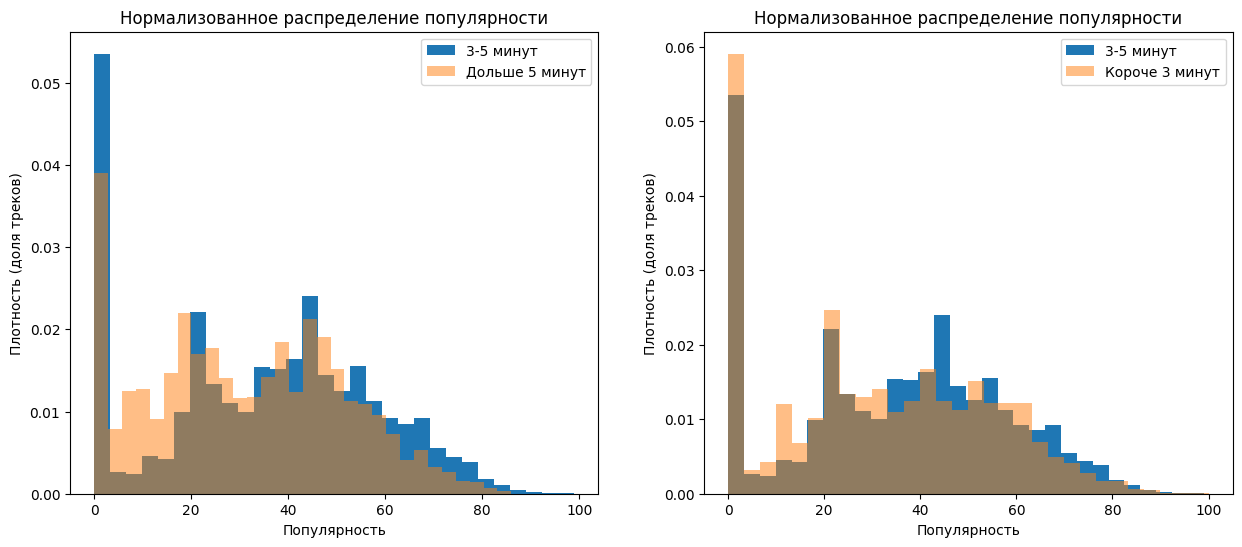

In [ ]:
# ПРОВЕРКА ГИПОТЕЗЫ: "Треки средней длительности (3-5 минут) наиболее популярны"
# -----------------------------------------------------------------

# ПЕРЕВОДИМ ДЛИТЕЛЬНОСТЬ ИЗ МИЛЛИСЕКУНД В МИНУТЫ
# -----------------------------------------------------------------
# Создаем новый столбец 'duration_min' в DataFrame df.
# Берем исходный столбец 'duration_ms' (длительность в миллисекундах)
# и делим на 60000 (количество миллисекунд в одной минуте).
# Теперь у нас есть длительность в минутах, что гораздо удобнее для анализа.
df['duration_min'] = df['duration_ms'] / 60000

# ВЫЧИСЛЯЕМ МЕДИАННУЮ ПОПУЛЯРНОСТЬ ДЛЯ ТРЕКОВ СРЕДНЕЙ ДЛИТЕЛЬНОСТИ
# -----------------------------------------------------------------
# df[(df['duration_min'] >= 3) & (df['duration_min'] <= 5)] - фильтруем датасет:
#   оставляем только те строки, где duration_min ОТ 3 ДО 5 минут включительно.
#   & - это логическое "И" (и то, и другое условие должны выполняться).
# ['popularity'] - из отфильтрованных строк берем только столбец популярности.
# .median() - вычисляем МЕДИАНУ популярности для этих треков.
medium_duration_median = df[(df['duration_min'] >= 3) & (df['duration_min'] <= 5)]['popularity'].median()

# ВЫЧИСЛЯЕМ МЕДИАННУЮ ПОПУЛЯРНОСТЬ ДЛЯ КОРОТКИХ ТРЕКОВ
# -----------------------------------------------------------------
# df[df['duration_min'] < 3] - фильтруем датасет:
#   оставляем только треки короче 3 минут.
# ['popularity'] - берем популярность.
# .median() - вычисляем медиану.
short_duration_median = df[df['duration_min'] < 3]['popularity'].median()

# ВЫЧИСЛЯЕМ МЕДИАННУЮ ПОПУЛЯРНОСТЬ ДЛЯ ДЛИННЫХ ТРЕКОВ
# -----------------------------------------------------------------
# df[df['duration_min'] > 5] - фильтруем датасет:
#   оставляем только треки длиннее 5 минут.
# ['popularity'] - берем популярность.
# .median() - вычисляем медиану.
long_duration_median = df[(df['duration_min'] > 5)]['popularity'].median()

# ВЫВОДИМ РЕЗУЛЬТАТЫ НА ЭКРАН
# -----------------------------------------------------------------
# print() - выводит текст и значения в консоль.
print(f'Медианная популярность треков 3-5 минут: {medium_duration_median}')
print(f'Медианная популярность треков короче 3 минут: {short_duration_median}')
print(f'Медианная популярность треков длиннее 5 минут: {long_duration_median}')

# СОЗДАЕМ ДВА ГРАФИКА РЯДОМ (SUBPOLTS)
# -----------------------------------------------------------------
# subplots(1, 2) - создает фигуру с 1 строкой и 2 столбцами графиков.
#   Мы получим две оси: ax1 (левый график) и ax2 (правый график).
# figsize=(15, 6) - задает общий размер фигуры: 15 дюймов в ширину, 6 в высоту.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 6))

# ЛЕВЫЙ ГРАФИК (ax1): Сравниваем средние (3-5 мин) и длинные (>5 мин) треки
# -----------------------------------------------------------------

# Строим гистограмму для треков СРЕДНЕЙ длительности (3-5 мин)
ax1.hist(df[(df['duration_min'] >= 3) & (df['duration_min'] <= 5)]['popularity'], 
         bins=30, label='3-5 минут', density=True)

# Строим гистограмму для ДЛИННЫХ треков (>5 мин)
# alpha=0.5 - делаем полупрозрачной, чтобы было видно пересечения.
ax1.hist(df[df['duration_min'] > 5]['popularity'], 
         bins=30, alpha=0.5, label='Дольше 5 минут', density=True)

# ПРАВЫЙ ГРАФИК (ax2): Сравниваем средние (3-5 мин) и короткие (<3 мин) треки
# -----------------------------------------------------------------

# Строим гистограмму для треков СРЕДНЕЙ длительности (3-5 мин)
ax2.hist(df[(df['duration_min'] >= 3) & (df['duration_min'] <= 5)]['popularity'], 
         bins=30, label='3-5 минут', density=True)

# Строим гистограмму для КОРОТКИХ треков (<3 мин)
# alpha=0.5 - делаем полупрозрачной.
ax2.hist(df[df['duration_min'] < 3]['popularity'], 
         bins=30, alpha=0.5, label='Короче 3 минут', density=True)

# НАСТРАИВАЕМ ПОДПИСИ ДЛЯ ЛЕВОГО ГРАФИКА (ax1)
# -----------------------------------------------------------------
ax1.set_xlabel('Популярность')              # Подпись оси X
ax1.set_ylabel('Плотность (доля треков)')   # Подпись оси Y (нормализованная гистограмма)
ax1.set_title('Нормализованное распределение популярности')  # Заголовок

# НАСТРАИВАЕМ ПОДПИСИ ДЛЯ ПРАВОГО ГРАФИКА (ax2)
# -----------------------------------------------------------------
ax2.set_xlabel('Популярность')              # Подпись оси X
ax2.set_ylabel('Плотность (доля треков)')   # Подпись оси Y
ax2.set_title('Нормализованное распределение популярности')  # Заголовок

# ДОБАВЛЯЕМ ЛЕГЕНДЫ (чтобы понять, где какая группа)
# -----------------------------------------------------------------
ax1.legend()  # Легенда для левого графика
ax2.legend()  # Легенда для правого графика

# ОТОБРАЖАЕМ ГОТОВЫЙ ГРАФИК
# -----------------------------------------------------------------
plt.show()

**Вывод: гипотеза подтвердилась - треки длительностью от 3 до 5 минут более высокую медианную популярность (37) по сравнению с короткими и длинными треками (30 и 30). Гистограммы показывают, что распределение популярности треков средней длительности имеет более высокую плотность в области средних и высоких значений популярности, в то время как у коротких треков преобладают низкие и средние значения, а у длинных треков распределение смещено к низким значениям популярности. Это свидетельствует о том, что оптимальная длительность для популярности составляет 3-5 минут, что соответствует стандартному формату современных музыкальных композиций.**

**Гипотеза: треки с наличием слов более популярны**

Медианная популярность треков с наличием слов: 29.0
Медианная популярность чисто музыкальных треков: 36.0


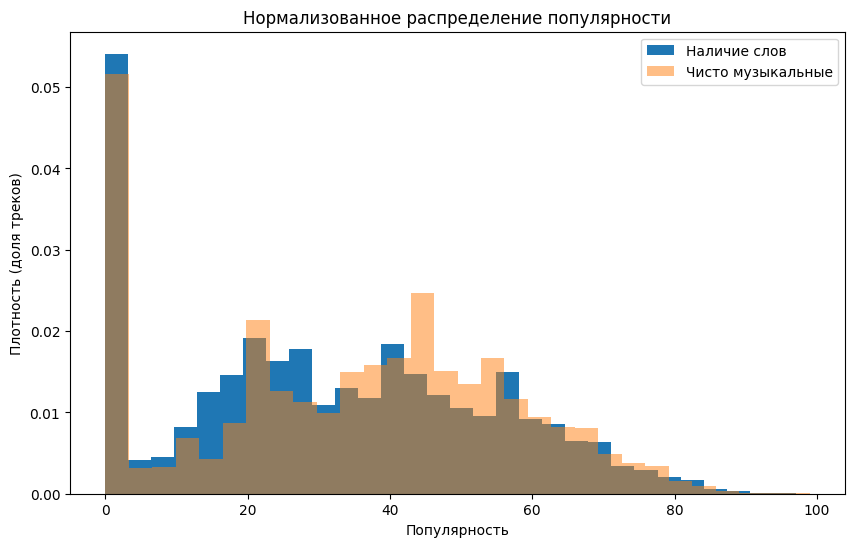

In [ ]:
# ПРОВЕРКА ГИПОТЕЗЫ: "Треки с наличием слов более популярны"
# -----------------------------------------------------------------

# ВЫЧИСЛЯЕМ МЕДИАННУЮ ПОПУЛЯРНОСТЬ ДЛЯ ТРЕКОВ С НАЛИЧИЕМ СЛОВ
# -----------------------------------------------------------------
# df[df['speechiness'] >= 0.1] - фильтруем датасет:
#   оставляем только те строки, где speechiness (наличие разговорной речи) 
#   больше или равен 0.1. Это треки, в которых есть слова (речь, рэп, вокал).
#   Значение 0.1 выбрано как порог, после которого можно говорить о наличии слов.
# ['popularity'] - из отфильтрованных строк берем только столбец популярности.
# .median() - вычисляем МЕДИАНУ популярности для этих треков.
moderate_speech_median = df[(df['speechiness'] >= 0.1)]['popularity'].median()

# ВЫЧИСЛЯЕМ МЕДИАННУЮ ПОПУЛЯРНОСТЬ ДЛЯ ЧИСТО МУЗЫКАЛЬНЫХ ТРЕКОВ
# -----------------------------------------------------------------
# df[df['speechiness'] < 0.1] - фильтруем датасет:
#   оставляем только те строки, где speechiness меньше 0.1.
#   Это треки, в которых практически нет слов (чисто инструментальная музыка).
# ['popularity'] - берем столбец популярности.
# .median() - вычисляем медиану популярности для чисто музыкальных треков.
no_speech_median = df[df['speechiness'] < 0.1]['popularity'].median()

# ВЫВОДИМ РЕЗУЛЬТАТЫ НА ЭКРАН
# -----------------------------------------------------------------
print(f'Медианная популярность треков с наличием слов: {moderate_speech_median}')
print(f'Медианная популярность чисто музыкальных треков: {no_speech_median}')

# СОЗДАЕМ ФИГУРУ И ОСИ ДЛЯ ГРАФИКА
# -----------------------------------------------------------------
# subplots() - создает фигуру (полотно) и набор осей для рисования.
# figsize=(10, 6) - задает размер графика: 10 дюймов в ширину, 6 в высоту.
fig, ax = plt.subplots(figsize=(10, 6))

# СТРОИМ ГИСТОГРАММУ ДЛЯ ТРЕКОВ С НАЛИЧИЕМ СЛОВ
# -----------------------------------------------------------------
# ВНИМАНИЕ! Здесь важное отличие от расчета медианы:
#   Для медианы мы брали все треки с speechiness >= 0.1.
#   Для гистограммы мы берем только треки с speechiness от 0.1 до 0.3.
#   Это сделано, чтобы исключить экстремальные случаи (например, стендап или аудиокниги)
#   и сосредоточиться на обычных треках с вокалом.
#
# df[(df['speechiness'] >= 0.1) & (df['speechiness'] <= 0.3)] - фильтруем датасет:
#   оставляем треки, где speechiness ОТ 0.1 ДО 0.3.
# & - логическое "И" (оба условия должны выполняться).
# ['popularity'] - берем популярность.
# bins=30 - разбиваем диапазон популярности на 30 корзин (интервалов).
# label='Наличие слов' - подпись для легенды.
# density=True - НОРМАЛИЗУЕМ гистограмму. По оси Y теперь не количество треков,
#                а ПЛОТНОСТЬ ВЕРОЯТНОСТИ. Площадь под гистограммой = 1.
ax.hist(df[(df['speechiness'] >= 0.1) & (df['speechiness'] <= 0.3)]['popularity'], 
        bins=30, label='Наличие слов', density=True)

# СТРОИМ ГИСТОГРАММУ ДЛЯ ЧИСТО МУЗЫКАЛЬНЫХ ТРЕКОВ
# -----------------------------------------------------------------
# df[df['speechiness'] < 0.05] - фильтруем датасет:
#   оставляем только треки с очень низкой речью (speechiness < 0.05).
#   Здесь используется более строгий порог (0.05 вместо 0.1), 
#   чтобы взять только "чисто музыкальные" треки без малейших следов речи.
# alpha=0.5 - делаем гистограмму полупрозрачной (прозрачность 50%),
#             чтобы было видно, где они перекрываются с первой гистограммой.
ax.hist(df[df['speechiness'] < 0.05]['popularity'], 
        bins=30, alpha=0.5, label='Чисто музыкальные', density=True)

# НАСТРАИВАЕМ ПОДПИСИ И ЗАГОЛОВОК
# -----------------------------------------------------------------
ax.set_xlabel('Популярность')                    # Подпись горизонтальной оси
ax.set_ylabel('Плотность (доля треков)')         # Подпись вертикальной оси (нормализованная)
ax.set_title('Нормализованное распределение популярности')  # Заголовок

# ДОБАВЛЯЕМ ЛЕГЕНДУ
# -----------------------------------------------------------------
ax.legend()  # Отображает легенду, используя подписи из label=...

# ОТОБРАЖАЕМ ГОТОВЫЙ ГРАФИК
# -----------------------------------------------------------------
plt.show()

**Вывод: гипотеза не подтвердилась - чисто музыкальные треки имеют значительно более высокую медианную популярность (36) по сравнению с треками с наличием слов (29). Нормализованная гистограмма показывает, что распределение популярности чисто музыкальных треков смещено в сторону высоких значений, с наибольшей плотностью в области средней и высокой популярности, в то время как треки с наличием слов демонстрируют более равномерное распределение по всему диапазону. Это свидетельствует о том, что слушатели предпочитают музыкальные композиции без речевых вставок, которые имеют больше шансов стать высокопопулярными.**

# Feature Engineering

**Гипотеза: синглы наиболее популярны чем треки из альбомов**


Количество треков:
Синглы: 20059
Треки из альбомов: 93941
Медианная популярность синглов: 47.0
Медианная популярность треков из альбомов: 29.0


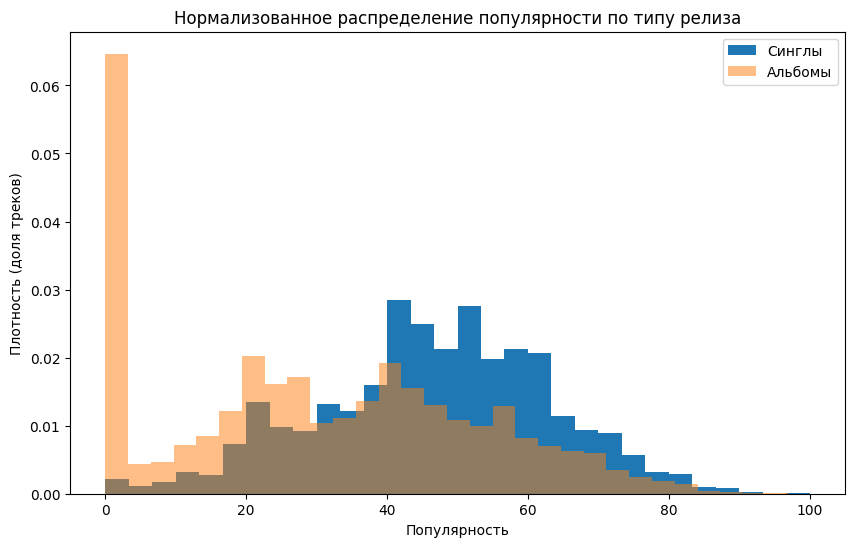

In [ ]:
# ПРОВЕРКА ГИПОТЕЗЫ: "Синглы наиболее популярны, чем треки из альбомов"
# -----------------------------------------------------------------

# СОЗДАЕМ НОВЫЙ ПРИЗНАК "ТИП РЕЛИЗА"
# -----------------------------------------------------------------
# Это гениальный ход! Мы создаем новый столбец на основе已有的 данных.
#
# (df['track_name'] == df['album_name']) - сравниваем два столбца поэлементно.
#   Если название трека совпадает с названием альбома, получаем True, иначе False.
#   Логика: если трек называется так же, как альбом, это скорее всего сингл. Если названия разные → это трек из альбома
#   Например, трек "Shape of You" из альбома "Shape of You" — это сингл.
#
# .astype(int) - преобразует True/False в числа: True -> 1, False -> 0.
#
# Результат сохраняем в новый столбец 'release_type'.
# Теперь у нас есть числовой признак: 1 - сингл, 0 - альбомный трек.
df['release_type'] = (df['track_name'] == df['album_name']).astype(int)

# ПОДСЧИТЫВАЕМ КОЛИЧЕСТВО ТРЕКОВ КАЖДОГО ТИПА
# -----------------------------------------------------------------
# len(df[df['release_type'] == 1]) - фильтруем датасет, оставляя только синглы,
#   и считаем количество таких строк.
single_count = len(df[df['release_type'] == 1])

# len(df[df['release_type'] == 0]) - фильтруем датасет, оставляя только альбомные треки,
#   и считаем их количество.
album_count = len(df[df['release_type'] == 0])

# ВЫЧИСЛЯЕМ МЕДИАННУЮ ПОПУЛЯРНОСТЬ ДЛЯ КАЖДОГО ТИПА
# -----------------------------------------------------------------
# df[df['release_type'] == 1]['popularity'] - берем популярность только синглов.
# .median() - вычисляем медиану.
single_median = df[df['release_type'] == 1]['popularity'].median()

# df[df['release_type'] == 0]['popularity'] - берем популярность альбомных треков.
album_median = df[df['release_type'] == 0]['popularity'].median()

# ВЫВОДИМ РЕЗУЛЬТАТЫ
# -----------------------------------------------------------------
print(f"\nКоличество треков:")
print(f"Синглы: {single_count}")          # 20,059 синглов
print(f"Треки из альбомов: {album_count}") # 93,941 альбомных треков
print(f'Медианная популярность синглов: {single_median}')        # 47.0
print(f'Медианная популярность треков из альбомов: {album_median}') # 29.0

# СОЗДАЕМ ГРАФИК ДЛЯ ВИЗУАЛИЗАЦИИ
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))  # Создаем полотно и оси

# СТРОИМ ГИСТОГРАММУ ДЛЯ СИНГЛОВ
# -----------------------------------------------------------------
# df[df['release_type'] == 1]['popularity'] - данные для гистограммы (популярность синглов)
# bins=30 - разбиваем на 30 корзин
# label='Синглы' - подпись для легенды
# density=True - нормализуем (площадь под гистограммой = 1)
ax.hist(df[df['release_type'] == 1]['popularity'], bins=30, label='Синглы', density=True)

# СТРОИМ ГИСТОГРАММУ ДЛЯ АЛЬБОМНЫХ ТРЕКОВ
# -----------------------------------------------------------------
# df[df['release_type'] == 0]['popularity'] - данные для гистограммы
# alpha=0.5 - делаем полупрозрачной, чтобы видеть пересечения
ax.hist(df[df['release_type'] == 0]['popularity'], bins=30, alpha=0.5, label='Альбомы', density=True)

# НАСТРАИВАЕМ ПОДПИСИ
# -----------------------------------------------------------------
ax.set_xlabel('Популярность')                    # Подпись оси X
ax.set_ylabel('Плотность (доля треков)')         # Подпись оси Y
ax.set_title('Нормализованное распределение популярности по типу релиза')  # Заголовок
ax.legend()  # Добавляем легенду

# ОТОБРАЖАЕМ ГРАФИК
# -----------------------------------------------------------------
plt.show()

**Вывод: гипотеза подтвердилась - синглы имеют значительно более высокую медианную популярность (47) по сравнению с треками из альбомов (29). Нормализованная гистограмма показывает, что распределение популярности синглов смещено в сторону высоких значений популярности по сравнению с альбомными, к тому же синглы имеют очень низкую плотность в области низких значений популярности (до 20), такого доминирования не наблюдается даже среди остальных признаков. Это свидетельствует о том, что синглы как отдельные релизы получают больше внимания, что увеличивает их шансы на высокую популярность по сравнению с треками, выпущенными в составе альбомов.**

**Извлечем теги из названий песен**

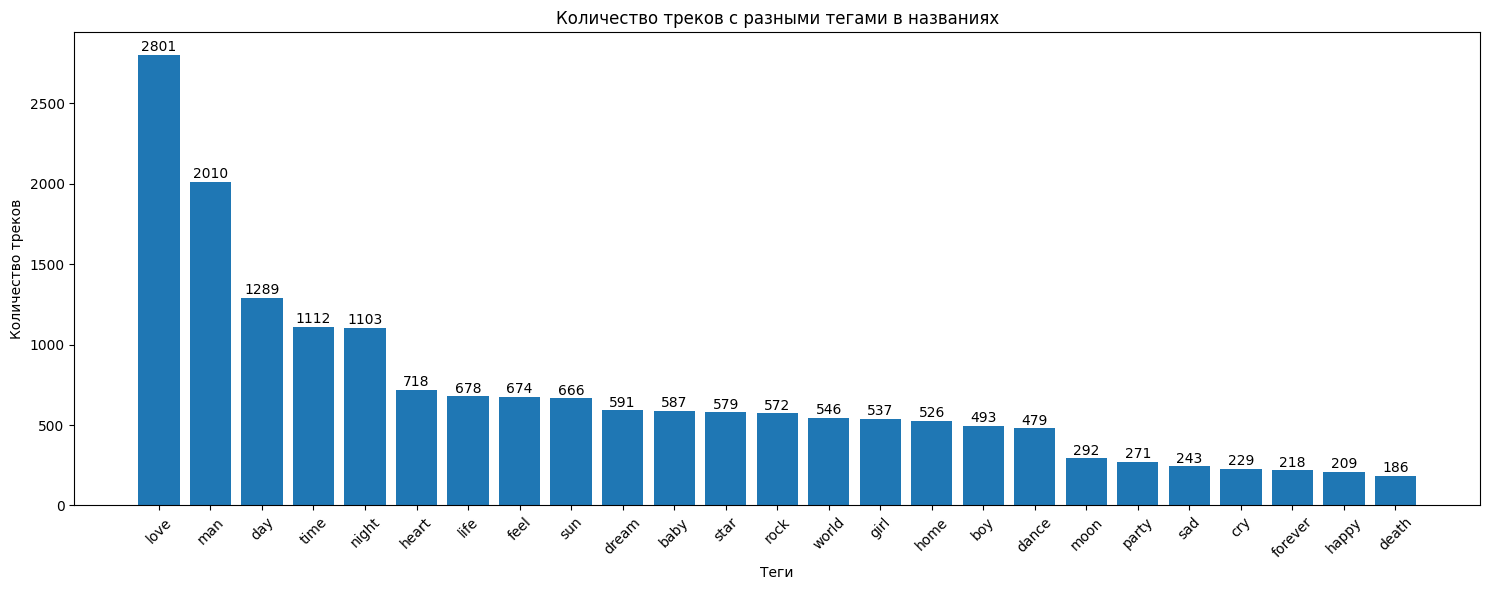

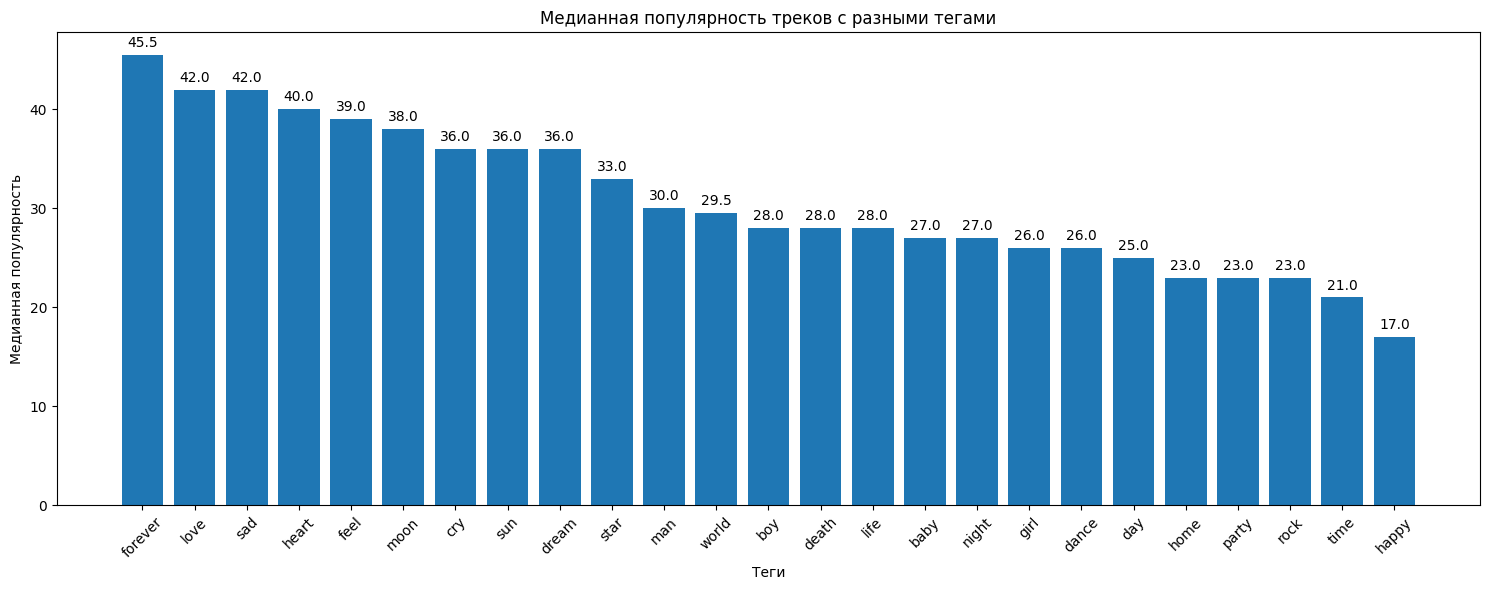

Статистика по тегам:
love: 2801 треков, популярность: 42.0
man: 2010 треков, популярность: 30.0
day: 1289 треков, популярность: 25.0
time: 1112 треков, популярность: 21.0
night: 1103 треков, популярность: 27.0
heart: 718 треков, популярность: 40.0
life: 678 треков, популярность: 28.0
feel: 674 треков, популярность: 39.0
sun: 666 треков, популярность: 36.0
dream: 591 треков, популярность: 36.0


In [ ]:
# ИЗВЛЕЧЕНИЕ ТЕГОВ ИЗ НАЗВАНИЙ ПЕСЕН
# -----------------------------------------------------------------

# СПИСОК ЧАСТЫХ СЛОВ В НАЗВАНИЯХ АНГЛИЙСКИХ ПЕСЕН
# -----------------------------------------------------------------
# Создаем список popular_words, содержащий часто встречающиеся слова в названиях песен.
# Эти слова выбраны на основе здравого смысла и популярных тем в музыке:
#   love (любовь) - самая популярная тема
#   baby (детка) - частое обращение
#   night (ночь), time (время), heart (сердце) - романтические темы
#   girl/boy (девушка/парень) - отношения
#   forever (навсегда), death (смерть), dance (танец) и т.д.
popular_words = [
    'love', 'baby', 'night', 'time', 'heart', 'girl', 'boy', 'home', 'world', 'life', 
    'dream', 'party', 'man', 'day', 'sun', 'moon', 'star',
    'feel', 'cry', 'happy', 'sad', 'forever', 'death', 'dance', 'rock'
]

# ФУНКЦИЯ ДЛЯ ИЗВЛЕЧЕНИЯ ТЕГОВ ИЗ НАЗВАНИЯ
# -----------------------------------------------------------------
def extract_tags(track_name):
    # Создаем пустой список для хранения найденных тегов
    tags = []
    
    # Преобразуем название трека в строку (на случай, если там не строка)
    # и переводим в нижний регистр, чтобы сравнивать без учета регистра
    track_name_lower = str(track_name).lower()
    
    # Перебираем все слова из списка popular_words
    for word in popular_words:
        # Если слово встречается в названии трека (in проверяет подстроку)
        if word in track_name_lower:
            # Добавляем слово в список тегов
            tags.append(word)
    
    # Объединяем все найденные теги в строку через запятую
    # Например: "love,heart,forever"
    return ','.join(tags)

# ДОБАВЛЯЕМ НОВУЮ КОЛОНКУ С ТЕГАМИ
# -----------------------------------------------------------------
# apply() - применяет функцию extract_tags к каждому элементу столбца 'track_name'.
# Результат (строку с тегами) сохраняем в новом столбце 'tags'.
# ТЕПЕРЬ У НАС НОВЫЙ ПРИЗНАК!
df['tags'] = df['track_name'].apply(extract_tags)

# АНАЛИЗ СТАТИСТИКИ ПО ТЕГАМ
# -----------------------------------------------------------------
# Создаем пустой список для хранения статистики по каждому тегу
tag_stats = []

# Перебираем все слова из списка popular_words
for word in popular_words:
    # df['tags'].str.contains(word, na=False) - проверяем, содержит ли столбец 'tags'
    #   данное слово. na=False означает, что пропуски (NaN) считаются как False.
    # df[...] - фильтруем датасет, оставляя только треки, содержащие этот тег.
    tag_tracks = df[df['tags'].str.contains(word, na=False)]
    
    # len() - считаем количество таких треков
    count = len(tag_tracks)
    
    # Вычисляем медианную популярность для этой группы треков
    median_popularity = tag_tracks['popularity'].median()
    
    # Добавляем словарь с данными по текущему тегу в список tag_stats
    tag_stats.append({
        'tag': word,                    # Название тега
        'count': count,                  # Количество треков с этим тегом
        'median_popularity': median_popularity  # Их медианная популярность
    })

# СОЗДАЕМ DATAFRAME СО СТАТИСТИКОЙ И СОРТИРУЕМ
# -----------------------------------------------------------------
# pd.DataFrame(tag_stats) - превращаем список словарей в таблицу DataFrame
# .sort_values('count', ascending=False) - сортируем по убыванию количества треков
tag_stats_df = pd.DataFrame(tag_stats).sort_values('count', ascending=False)

# ВИЗУАЛИЗАЦИЯ 1: КОЛИЧЕСТВО ТРЕКОВ ПО ТЕГАМ
# -----------------------------------------------------------------
plt.figure(figsize=(15, 6))  # Создаем фигуру размером 15x6 дюймов

# Строим столбчатую диаграмму:
#   tag_stats_df['tag'] - названия тегов по оси X
#   tag_stats_df['count'] - количество треков по оси Y
plt.bar(tag_stats_df['tag'], tag_stats_df['count'])

# Добавляем заголовок и подписи осей
plt.title('Количество треков с разными тегами в названиях')
plt.xlabel('Теги')
plt.ylabel('Количество треков')

# Поворачиваем подписи тегов на 45 градусов, чтобы они не налезали друг на друга
plt.xticks(rotation=45)

# Добавляем числовые подписи над каждым столбцом
for i, count in enumerate(tag_stats_df['count']):
    # i - индекс столбца, count - его высота
    # Текст размещаем на 5 единиц выше столбца, по центру
    plt.text(i, count + 5, str(count), ha='center', va='bottom')

plt.tight_layout()  # Автоматически подгоняем элементы графика
plt.show()  # Отображаем график

# ВИЗУАЛИЗАЦИЯ 2: МЕДИАННАЯ ПОПУЛЯРНОСТЬ ПО ТЕГАМ
# -----------------------------------------------------------------
# Сортируем таблицу по убыванию медианной популярности
tag_stats_sorted = tag_stats_df.sort_values('median_popularity', ascending=False)

plt.figure(figsize=(15, 6))  # Создаем новую фигуру

# Строим столбчатую диаграмму популярности
plt.bar(tag_stats_sorted['tag'], tag_stats_sorted['median_popularity'])

plt.title('Медианная популярность треков с разными тегами')
plt.xlabel('Теги')
plt.ylabel('Медианная популярность')
plt.xticks(rotation=45)

# Добавляем числовые подписи над каждым столбцом
for i, popularity in enumerate(tag_stats_sorted['median_popularity']):
    # Текст размещаем на 0.5 единицы выше столбца, с одним знаком после запятой
    plt.text(i, popularity + 0.5, f'{popularity:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ВЫВОД СТАТИСТИКИ В КОНСОЛЬ
# -----------------------------------------------------------------
print("Статистика по тегам:")
# Берем первые 10 строк отсортированной таблицы (самые популярные по частоте)
for _, row in tag_stats_df.head(10).iterrows():
    # Выводим тег, количество треков и медианную популярность
    print(f"{row['tag']}: {row['count']} треков, популярность: {row['median_popularity']:.1f}")

**Больше всего песен с тегами love, man, day, time, night, но самая высокая медианная популярность у треков с тегом forever (45.5). Далее идут love (42), sad (42) и heart (40). Это показывает, что частотность тега не всегда коррелирует с популярностью - теги, связанные с вечностью и глубокими эмоциями, имеют более высокую популярность, чем более распространенные бытовые темы.** 

Этот признак (tags) добавит модели информацию о тематике песни, что может помочь в предсказании популярности.

**Гипотеза: треки с наличием коллаборации имеют более высокую популярность, чем треки без нее.**

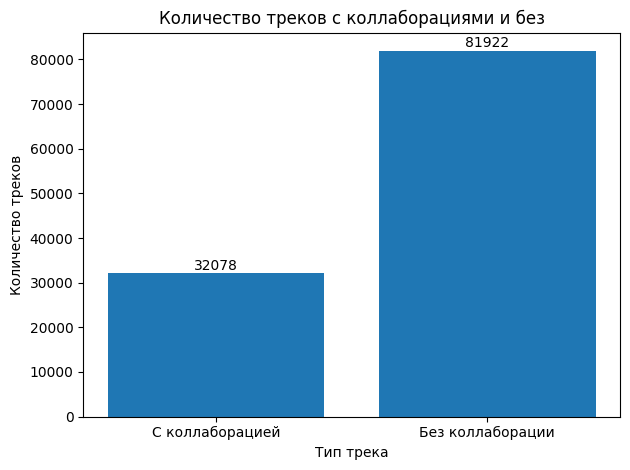

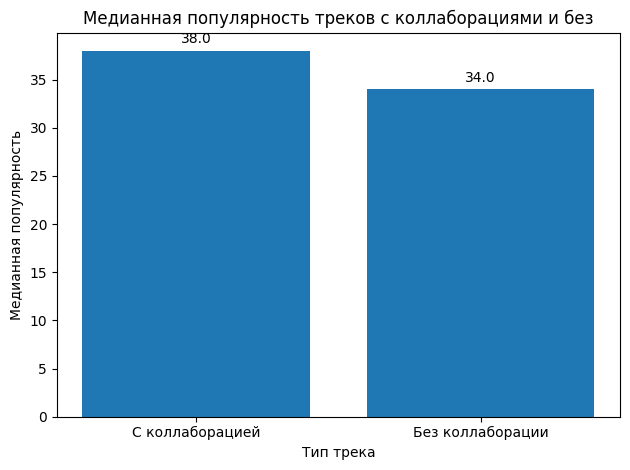

In [ ]:
# ПРОВЕРКА ГИПОТЕЗЫ: "Треки с коллаборациями более популярны"
# -----------------------------------------------------------------

# ФУНКЦИЯ ДЛЯ ОПРЕДЕЛЕНИЯ НАЛИЧИЯ КОЛЛАБОРАЦИЙ
# -----------------------------------------------------------------
def has_collaboration(artists):
    # Преобразуем входное значение в строку (на случай, если там не строка)
    artists_str = str(artists)
    
    # Проверяем наличие разделителей, указывающих на нескольких исполнителей:
    # ';' - часто используется как разделитель в данных Spotify
    # '&' - союз "и" (например, "Smith & Jones")
    # ',' - запятая (например, "Smith, Jones")
    # if any of these are in the string, then it's a collaboration
    has_multiple_artists = ';' in artists_str or '&' in artists_str or ',' in artists_str
    
    # Возвращаем True (есть коллаборация) или False (нет коллаборации)
    return has_multiple_artists

# ДОБАВЛЯЕМ НОВУЮ КОЛОНКУ С ИНФОРМАЦИЕЙ О КОЛЛАБОРАЦИЯХ
# -----------------------------------------------------------------
# apply() - применяет функцию к каждой строке DataFrame
# lambda x: has_collaboration(x['artists']) - создаем анонимную функцию,
#   которая берет значение из колонки 'artists' текущей строки и передает его
#   в функцию has_collaboration
# axis=1 - указываем, что применяем функцию к каждой строке (а не к каждому столбцу)
# .astype(int) - преобразуем результат (True/False) в числа (1/0)
# Результат сохраняем в новом столбце 'has_collaboration'
# ТЕПЕРЬ У НАС НОВЫЙ ПРИЗНАК!
df['has_collaboration'] = (df.apply(lambda x: has_collaboration(x['artists']), axis=1)).astype(int)

# АНАЛИЗ СТАТИСТИКИ ПО НАЛИЧИЮ КОЛЛАБОРАЦИЙ
# -----------------------------------------------------------------
# Создаем пустой список для хранения статистики
collab_stats = []

# Определяем типы для анализа: 1 - с коллаборацией, 0 - без
collab_types = [1, 0]

# Перебираем оба типа
for has_collab in collab_types:
    # Фильтруем датасет: оставляем только треки с текущим типом коллаборации
    collab_tracks = df[df['has_collaboration'] == has_collab]
    
    # Считаем количество таких треков
    count = len(collab_tracks)
    
    # Вычисляем МЕДИАННУЮ популярность (устойчива к выбросам)
    median_popularity = collab_tracks['popularity'].median()
    
    # Вычисляем СРЕДНЮЮ популярность (для информации, но в итоге не используется)
    mean_popularity = collab_tracks['popularity'].mean()
    
    # Добавляем словарь с данными в список collab_stats
    collab_stats.append({
        # Тернарный оператор: если has_collab == 1, то 'С коллаборацией', иначе 'Без коллаборации'
        'has_collaboration': 'С коллаборацией' if has_collab else 'Без коллаборации',
        'count': count,
        'median_popularity': median_popularity
    })

# СОЗДАЕМ DATAFRAME СО СТАТИСТИКОЙ
# -----------------------------------------------------------------
# Превращаем список словарей в таблицу DataFrame
collab_stats_df = pd.DataFrame(collab_stats)

# ВИЗУАЛИЗАЦИЯ 1: КОЛИЧЕСТВО ТРЕКОВ
# -----------------------------------------------------------------
plt.figure()  # Создаем новое полотно для графика

# Строим столбчатую диаграмму:
#   collab_stats_df['has_collaboration'] - подписи по оси X ("С коллаборацией", "Без коллаборации")
#   collab_stats_df['count'] - высота столбцов (количество треков)
plt.bar(collab_stats_df['has_collaboration'], collab_stats_df['count'])

plt.title('Количество треков с коллаборациями и без')  # Заголовок
plt.xlabel('Тип трека')  # Подпись оси X
plt.ylabel('Количество треков')  # Подпись оси Y

# Добавляем числовые подписи над каждым столбцом
for i, count in enumerate(collab_stats_df['count']):
    # i - индекс столбца (0 или 1)
    # count - количество треков
    # Текст размещаем на 100 единиц выше столбца, по центру
    plt.text(i, count + 100, str(count), ha='center', va='bottom')

plt.tight_layout()  # Автоматически подгоняем элементы графика
plt.show()  # Отображаем график

# ВИЗУАЛИЗАЦИЯ 2: МЕДИАННАЯ ПОПУЛЯРНОСТЬ
# -----------------------------------------------------------------
plt.figure()  # Создаем новое полотно для второго графика

# Строим столбчатую диаграмму популярности
plt.bar(collab_stats_df['has_collaboration'], collab_stats_df['median_popularity'])

plt.title('Медианная популярность треков с коллаборациями и без')
plt.xlabel('Тип трека')
plt.ylabel('Медианная популярность')

# Добавляем числовые подписи над каждым столбцом
for i, popularity in enumerate(collab_stats_df['median_popularity']):
    # Текст размещаем на 0.5 единицы выше столбца, с одним знаком после запятой
    plt.text(i, popularity + 0.5, f'{popularity:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Вывод: гипотеза подтвердилась - треки с коллаборациями имеют немного более высокую медианную популярность (38.0) по сравнению с треками без коллабораций (34.0). Это свидетельствует о том, что наличие коллабораций влияет на популярность треков, но несильно и не является определяющим фактором успеха.**

**Сгруппируем жанры треков по категориям**

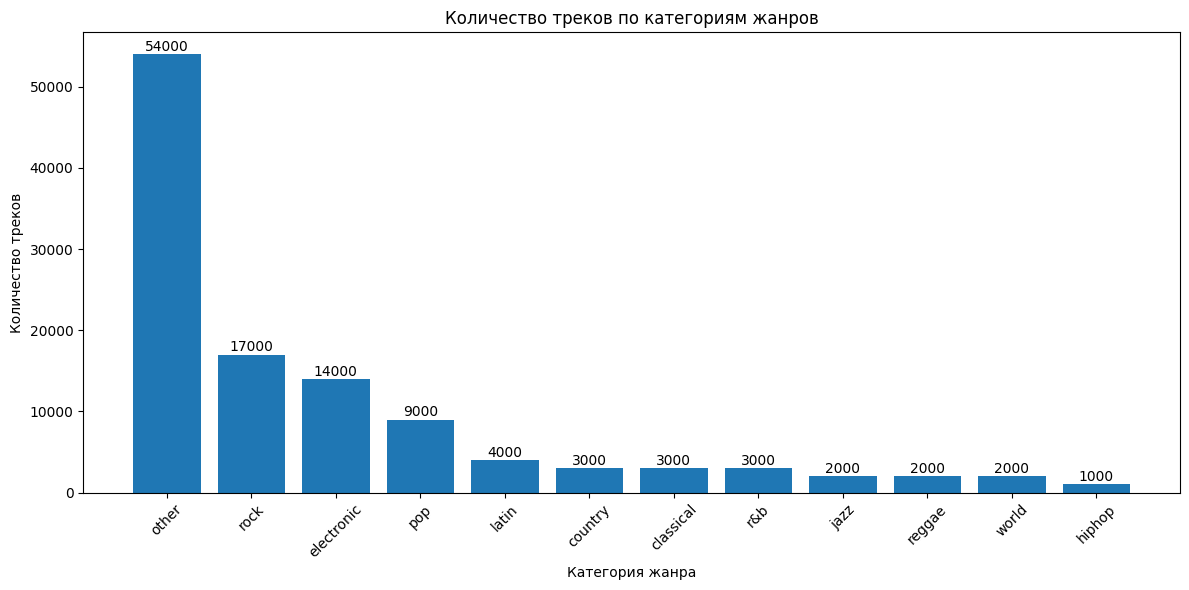

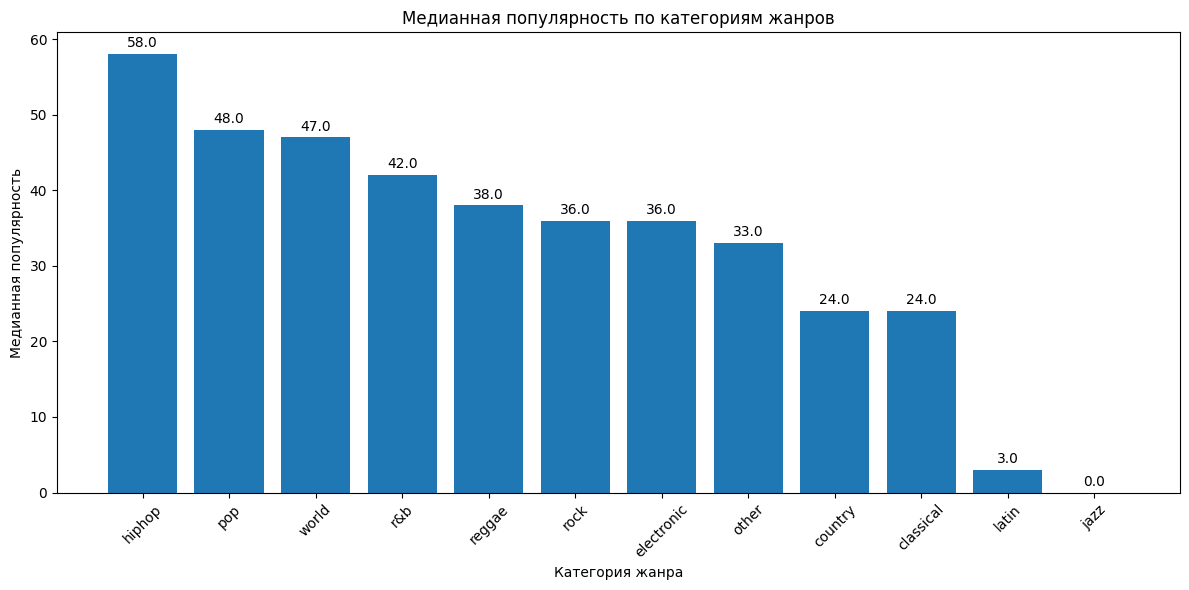

Статистика по категориям жанров:
other: 54000 треков, популярность: 33.0
rock: 17000 треков, популярность: 36.0
electronic: 14000 треков, популярность: 36.0
pop: 9000 треков, популярность: 48.0
latin: 4000 треков, популярность: 3.0
country: 3000 треков, популярность: 24.0
classical: 3000 треков, популярность: 24.0
r&b: 3000 треков, популярность: 42.0
jazz: 2000 треков, популярность: 0.0
reggae: 2000 треков, популярность: 38.0
world: 2000 треков, популярность: 47.0
hiphop: 1000 треков, популярность: 58.0


In [ ]:
# ГРУППИРОВКА ЖАНРОВ ПО МУЗЫКАЛЬНЫМ КАТЕГОРИЯМ
# -----------------------------------------------------------------
# Это словарь, где ключ - название категории (например, 'pop'),
# а значение - список конкретных жанров, которые входят в эту категорию.
# Это нужно, чтобы объединить множество мелких жанров в осмысленные группы.
genre_groups = {
    # Поп-музыка и ее разновидности
    'pop': ['pop', 'k-pop', 'j-pop', 'indie-pop', 'synth-pop', 'power-pop'],
    
    # Рок и его поджанры
    'rock': ['rock', 'alternative', 'indie', 'punk', 'hard-rock', 'metal', 'grunge'],
    
    # Хип-хоп и рэп
    'hiphop': ['hip-hop', 'rap', 'trap', 'gangster-rap'],
    
    # Электронная музыка
    'electronic': ['electronic', 'edm', 'dubstep', 'house', 'techno', 'trance', 'dance'],
    
    # R&B, соул, фанк
    'r&b': ['r-n-b', 'soul', 'funk'],
    
    # Латиноамериканская музыка
    'latin': ['latin', 'reggaeton', 'salsa', 'bachata'],
    
    # Кантри и фолк
    'country': ['country', 'folk', 'bluegrass'],
    
    # Джаз и блюз
    'jazz': ['jazz', 'blues'],
    
    # Классическая музыка
    'classical': ['classical', 'opera', 'piano'],
    
    # Регги
    'reggae': ['reggae', 'dub'],
    
    # Мировая музыка
    'world': ['world-music', 'african', 'indian']
}

# ФУНКЦИЯ ДЛЯ КАТЕГОРИЗАЦИИ ЖАНРОВ
# -----------------------------------------------------------------
def categorize_genre(genre):
    # Если жанр отсутствует (NaN), относим к категории 'other' (другое)
    if pd.isna(genre):
        return 'other'
    
    # Преобразуем жанр в строку и переводим в нижний регистр
    # для сравнения без учета регистра
    genre_str = str(genre).lower()
    
    # Перебираем все категории из словаря genre_groups
    for category, genres in genre_groups.items():
        # any() - возвращает True, если хотя бы одно условие истинно
        # Проверяем, содержится ли какой-либо жанр из списка genres
        # в строке genre_str (in проверяет вхождение подстроки)
        if any(g in genre_str for g in genres):
            return category  # Возвращаем название категории
    
    # Если ни одна категория не подошла, возвращаем 'other'
    return 'other'

# ДОБАВЛЯЕМ НОВУЮ КОЛОНКУ С КАТЕГОРИЕЙ ЖАНРА
# -----------------------------------------------------------------
# apply() - применяем функцию categorize_genre к каждому элементу столбца 'track_genre'
# Результат (название категории) сохраняем в новом столбце 'genre_category'
# ТЕПЕРЬ У НАС НОВЫЙ ПРИЗНАК!
df['genre_category'] = df['track_genre'].apply(categorize_genre)   #.apply(categorize_genre) — применяет функцию categorize_genre к каждому значению в этой колонке

#Функция categorize_genre преобразует конкретный жанр в категорию ('pop', 'rock', 'hiphop', и т.д.)

# АНАЛИЗ СТАТИСТИКИ ПО КАТЕГОРИЯМ ЖАНРОВ
# -----------------------------------------------------------------
# Создаем пустой список для хранения статистики
genre_stats = []

# Перебираем все уникальные категории из столбца 'genre_category'
for category in df['genre_category'].unique():  #убирает повторения 
    # Фильтруем датасет: оставляем только треки текущей категории
    genre_tracks = df[df['genre_category'] == category]
    
    # Считаем количество треков в этой категории
    count = len(genre_tracks)
    
    # Вычисляем МЕДИАННУЮ популярность для этой категории
    # Медиана выбрана, потому что распределение популярности сильно искажено
    median_popularity = genre_tracks['popularity'].median()
    
    # Добавляем словарь с данными в список genre_stats
    genre_stats.append({
        'genre_category': category,      # Название категории
        'count': count,                   # Количество треков
        'median_popularity': median_popularity  # Медианная популярность
    })

# СОЗДАЕМ DATAFRAME СО СТАТИСТИКОЙ И СОРТИРУЕМ
# -----------------------------------------------------------------
# pd.DataFrame(genre_stats) - превращаем список словарей в таблицу DataFrame
# .sort_values('count', ascending=False) - сортируем по убыванию количества треков
genre_stats_df = pd.DataFrame(genre_stats).sort_values('count', ascending=False)

# ВИЗУАЛИЗАЦИЯ 1: КОЛИЧЕСТВО ТРЕКОВ ПО КАТЕГОРИЯМ
# -----------------------------------------------------------------
plt.figure(figsize=(12, 6))  # Создаем фигуру размером 12x6 дюймов

# Строим столбчатую диаграмму:
#   genre_stats_df['genre_category'] - названия категорий по оси X
#   genre_stats_df['count'] - количество треков по оси Y
plt.bar(genre_stats_df['genre_category'], genre_stats_df['count'])

plt.title('Количество треков по категориям жанров')  # Заголовок
plt.xlabel('Категория жанра')  # Подпись оси X
plt.ylabel('Количество треков')  # Подпись оси Y

# Поворачиваем подписи категорий на 45 градусов, чтобы они не налезали друг на друга
plt.xticks(rotation=45)

# Добавляем числовые подписи над каждым столбцом
for i, count in enumerate(genre_stats_df['count']):
    # i - индекс столбца, count - его высота
    # Текст размещаем на 50 единиц выше столбца, по центру
    plt.text(i, count + 50, str(count), ha='center', va='bottom')

plt.tight_layout()  # Автоматически подгоняем элементы графика
plt.show()  # Отображаем график

# ВИЗУАЛИЗАЦИЯ 2: МЕДИАННАЯ ПОПУЛЯРНОСТЬ ПО КАТЕГОРИЯМ
# -----------------------------------------------------------------
# Сортируем таблицу по убыванию медианной популярности
genre_stats_sorted = genre_stats_df.sort_values('median_popularity', ascending=False)

plt.figure(figsize=(12, 6))  # Создаем новую фигуру

# Строим столбчатую диаграмму популярности
plt.bar(genre_stats_sorted['genre_category'], genre_stats_sorted['median_popularity'])

plt.title('Медианная популярность по категориям жанров')
plt.xlabel('Категория жанра')
plt.ylabel('Медианная популярность')
plt.xticks(rotation=45)

# Добавляем числовые подписи над каждым столбцом
for i, popularity in enumerate(genre_stats_sorted['median_popularity']):
    # Текст размещаем на 0.5 единицы выше столбца, с одним знаком после запятой
    plt.text(i, popularity + 0.5, f'{popularity:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ВЫВОД СТАТИСТИКИ В КОНСОЛЬ
# -----------------------------------------------------------------
print("Статистика по категориям жанров:")
# iterrows() - проходим по всем строкам DataFrame
for i, row in genre_stats_df.iterrows():
    # Выводим категорию, количество треков и медианную популярность
    Когда мы спрашиваем: "Какова типичная популярность рок-треков?" — мы хотим понять, какая популярность характерна для большинства треков этого жанра.

Среднее скажет: "Средняя популярность рока = 36"

Медиана скажет: "Половина рок-треков имеет популярность ≤ 36, половина — ≥ 36"

Второе гораздо информативнее, особенно когда распределение искажено.
    print(f"{row['genre_category']}: {row['count']} треков, популярность: {row['median_popularity']:.1f}")

**Создание музыкальных профилей**

**Вывод: Категория hiphop демонстрирует наивысшую медианную популярность (58.0), значительно опережая следующие за ней pop (48.0) и world (47.0). Самую низкую медианную популярность имеют категории latin (3) и jazz (0), что свидетельствует о их исключительно нишевом характере и ограниченной аудитории на платформе Spotify, возможно из-за специфики музыкальных предпочтений основной пользовательской базы или особенностей продвижения данного жанра.**

Зачем нужны музыкальные профили?
Это очень продвинутый Feature Engineering! Вы не просто используете сырые признаки, а создаете новые, более сложные характеристики, которые могут лучше отражать музыкальную суть трека.

Основная идея
Отдельные аудио-характеристики (танцевальность, энергия, акустичность) могут быть не так важны по отдельности, но их комбинация может дать более сильный сигнал для модели.

Что такое музыкальные профили?
Энергетический профиль (energy_profile):

Комбинация danceability (танцевальность) и energy (энергия)

Зачем: Танцевальность и энергия часто correlated. Вместе они могут лучше описывать "качающий" характер трека, чем по отдельности.

Эмоциональный профиль (mood_profile):

Комбинация mode (лад: мажор/минор) и valence (позитивность)

Зачем: Лад и валентность вместе определяют эмоциональную окраску. Мажор + высокая валентность = счастливая песня. Минор + низкая валентность = грустная.

Акустико-инструментальный профиль (acoustic_instrumental_profile):

Комбинация acousticness (акустичность) и instrumentalness (инструментальность)

Зачем: Акустические и инструментальные треки часто похожи по звучанию. Вместе они могут лучше выделять "живое", неэлектронное звучание.

Почему нужно выбирать между сложением и умножением?
Разные комбинации по-разному влияют на результат:

Сложение (+): Хорошо, когда признаки дополняют друг друга. Высокое значение хотя бы одного признака дает высокий профиль.

Умножение (*): Хорошо, когда важны оба признака одновременно. Профиль будет высоким, только если оба признака высокие.

Мы не знаем заранее, какая комбинация лучше. Поэтому мы тестируем обе и выбираем ту, у которой выше корреляция с популярностью.


In [ ]:
# СОЗДАНИЕ МУЗЫКАЛЬНЫХ ПРОФИЛЕЙ (FEATURE ENGINEERING)
# -----------------------------------------------------------------

# ЭНЕРГЕТИЧЕСКИЙ ПРОФИЛЬ (танцевальность И/ИЛИ энергия)
# -----------------------------------------------------------------
# Эти строки закомментированы, потому что мы сначала хотим выбрать лучшую комбинацию
# df['energy_profile'] = df['danceability'] */+ df['energy']

# ЭМОЦИОНАЛЬНЫЙ ПРОФИЛЬ (лад И/ИЛИ валентность)
# -----------------------------------------------------------------
# df['mood_profile'] = df['mode'] */+ df['valence']

# АКУСТИКО-ИНСТРУМЕНТАЛЬНЫЙ ПРОФИЛЬ (акустичность И/ИЛИ инструментальность)
# -----------------------------------------------------------------
# df['acoustic_instrumental_profile'] = df['acousticness'] */+ df['instrumentalness']

# СРАВНЕНИЕ КОМБИНАЦИЙ (ВЫБИРАЕМ ЛУЧШУЮ)
# -----------------------------------------------------------------

# ЭНЕРГЕТИЧЕСКИЙ ПРОФИЛЬ: сравниваем сложение и умножение
# -----------------------------------------------------------------
# (df['danceability'] + df['energy']) - создаем временный ряд (сумма двух признаков)
# .corr(df['popularity']) - вычисляем корреляцию этого ряда с популярностью
# Корреляция показывает, насколько сильно связаны эти два показателя
energy_add = (df['danceability'] + df['energy']).corr(df['popularity'])

# (df['danceability'] * df['energy']) - произведение двух признаков
energy_mult = (df['danceability'] * df['energy']).corr(df['popularity'])

# ЭМОЦИОНАЛЬНЫЙ ПРОФИЛЬ: сравниваем сложение и умножение
# -----------------------------------------------------------------
# mode - это лад (0 - минор, 1 - мажор)
# valence - позитивность (0 - грустный, 1 - позитивный)
mood_add = (df['mode'] + df['valence']).corr(df['popularity'])
mood_mult = (df['mode'] * df['valence']).corr(df['popularity'])

# АКУСТИКО-ИНСТРУМЕНТАЛЬНЫЙ ПРОФИЛЬ: сравниваем сложение и умножение
# -----------------------------------------------------------------
acoustic_add = (df['acousticness'] + df['instrumentalness']).corr(df['popularity'])
acoustic_mult = (df['acousticness'] * df['instrumentalness']).corr(df['popularity'])

# ВЫВОДИМ РЕЗУЛЬТАТЫ СРАВНЕНИЯ
# -----------------------------------------------------------------
# :.3f - форматируем число с тремя знаками после запятой
print(f"Энергетический профиль - сложение: {energy_add:.3f}, умножение: {energy_mult:.3f}")
print(f"Эмоциональный профиль - сложение: {mood_add:.3f}, умножение: {mood_mult:.3f}")
print(f"Акустико-инструментальный профиль - сложение: {acoustic_add:.3f}, умножение: {acoustic_mult:.3f}")

# ДОБАВЛЯЕМ ПРИЗНАКИ С ЛУЧШЕЙ КОМБИНАЦИЕЙ
# -----------------------------------------------------------------
# ТЕПЕРЬ МЫ СОЗДАЕМ НОВЫЕ СТОЛБЦЫ!

# Для энергетического профиля сложение дало лучшую корреляцию (0.020 против 0.006)
# Создаем новый признак 'energy_profile' как сумму танцевальности и энергии
df['energy_profile'] = df['danceability'] + df['energy']  # сложение лучше

# Для эмоционального профиля умножение дало лучшую корреляцию (-0.037 против -0.031)
# Создаем новый признак 'mood_profile' как произведение лада и валентности
df['mood_profile'] = df['mode'] * df['valence']  # умножение лучше

# Для акустико-инструментального профиля сложение дало лучшую корреляцию (-0.079 против -0.041)
# Создаем новый признак как сумму акустичности и инструментальности
df['acoustic_instrumental_profile'] = df['acousticness'] + df['instrumentalness']  # сложение лучше
df['acoustic_instrumental_profile'] = df['acousticness'] + df['instrumentalness']  # сложение лучше

Энергетический профиль - сложение: 0.020, умножение: 0.006
Эмоциональный профиль - сложение: -0.031, умножение: -0.037
Акустико-инструментальный профиль - сложение: -0.079, умножение: -0.041


Анализ результатов:
Энергетический профиль: Сложение (0.020) лучше умножения (0.006). Это значит, что танцевальность и энергия дополняют друг друга. Если трек танцевальный ИЛИ энергичный, он уже имеет шанс на популярность.

Эмоциональный профиль: Умножение (-0.037) лучше сложения (-0.031). Хотя корреляция отрицательная (что интересно!), умножение дает более сильную связь. Это значит, что для популярности важно сочетание лада и валентности, а не что-то одно.

Акустико-инструментальный профиль: Сложение (-0.079) лучше умножения (-0.041). Отрицательная корреляция означает, что чем выше акустичность и инструментальность, тем ниже популярность. Это подтверждает вашу раннюю гипотезу об инструментальных треках.

Почему это важно?
Новые признаки: Мы создали три новых признака, которые могут быть полезны для модели.

Улучшение модели: Даже небольшое улучшение корреляции может привести к более точным предсказаниям.

Понимание данных: Мы узнали, как разные комбинации признаков связаны с популярностью.

-0.079 дальше от нуля, чем -0.041, значит, связь сильнее.

Почему отрицательная корреляция — это тоже хорошо?
Отрицательная корреляция означает обратную связь:

Чем выше акустичность и инструментальность, тем ниже популярность.

Это подтверждает вашу гипотезу из EDA! Инструментальные и акустические треки менее популярны. Модель сможет использовать этот признак, чтобы "штрафовать" такие треки.

# Корреляция

In [ ]:
#Подготовка данных
df = df.drop(['Unnamed: 0', 'duration_ms', 'track_id'], axis=1) #Убираем лишние признаки

#Преобразование некоторых признаков в числовой тип
df['explicit'] = (df['explicit']).astype(int)
df['genre_category'] = df['genre_category'].astype('category').cat.codes

explicit — булевы значения в числа
Исходно explicit имел тип bool (True/False)

Модели машинного обучения работают с числами, поэтому мы преобразуем:

True → 1

False → 0

genre_category — категории в числа
genre_category — это текстовые категории ('pop', 'rock', 'hiphop', и т.д.)

Мы преобразуем их в числовые коды:

'pop' → 0

'rock' → 1

'hiphop' → 2

и так далее

Почему не TargetEncoder?

genre_category уже содержит всего около 10-12 категорий

Можно было бы использовать TargetEncoder и здесь, но для небольшого числа категорий прямое кодирование тоже работает

Важно, что мы делаем это после разделения на train/test, чтобы не было утечки данных

Резюме
Мы удаляем:

Unnamed: 0 — бесполезный индекс

duration_ms — дубликат duration_min

track_id — уникальный идентификатор, бесполезный для обучения

Оставляем только признаки, которые действительно могут помочь модели предсказывать популярность.

В "Титанике" вы использовали три метода, потому что у вас были разные типы данных (категориальные, порядковые, бинарные) и нужно было убедиться, что выводы не зависят от метода.

В вашем проекте Spotify все признаки уже числовые, поэтому метода Пирсона достаточно для понимания линейных связей. А нелинейные связи найдут уже сами модели (XGBoost, Decision Tree).
1. Типы данных и методы корреляции
Метод	Для каких данных	Что измеряет
Пирсон	Числовые данные (непрерывные)	Линейную связь
Спирмен	Порядковые (ранговые) данные	Монотонную (не обязательно линейную) связь
Кендалл	Категориальные данные, малые выборки	Согласованность порядков

Изначально НЕ числовые признаки (требовали кодирования):
Признак	Тип	Описание
track_id	object	Уникальный идентификатор (бесполезен)
artists	object	Имена исполнителей
album_name	object	Название альбома
track_name	object	Название трека
track_genre	object	Жанр трека
Признаки, которые мы создали сами (Feature Engineering):
Признак	Как создали	Описание
duration_min	duration_ms / 60000	Длительность в минутах
release_type	track_name == album_name	Сингл (1) или альбомный трек (0)
tags	Извлечение ключевых слов из названия	Теги из названия
has_collaboration	Проверка наличия ';', '&', ',' в artists	Есть ли несколько исполнителей
genre_category	Группировка жанров	'pop', 'rock', 'hiphop' и т.д.
energy_profile	danceability + energy	Энергетический профиль
mood_profile	mode * valence	Эмоциональный профиль
acoustic_instrumental_profile	acousticness + instrumentalness	Акустико-инструментальный профиль
Так какие признаки были закодированы изначально?
Некоторые да, но не все.

Уже закодированы изначально:
key — тональность уже была представлена числами от 0 до 11

mode — лад уже был 0 или 1

time_signature — музыкальный размер уже был числом (3, 4, 5 и т.д.)

Не закодированы изначально (мы кодировали их сами):
artists — текст → мы использовали для создания has_collaboration и TargetEncoder

album_name — текст → использовали для создания release_type и TargetEncoder

track_name — текст → использовали для создания release_type, tags и TargetEncoder

track_genre — текст → преобразовали в genre_category и затем в числа

Почему мы не использовали OneHotEncoder?
Вы правильно выбрали TargetEncoder для текстовых признаков, потому что:

Уникальных значений очень много (например, тысячи уникальных artists)

OneHotEncoder создал бы тысячи новых признаков → "проклятие размерности"

TargetEncoder заменяет каждую категорию на среднюю популярность для этой категории, что напрямую отражает влияние на целевую переменную

Резюме
Тип признаков	Примеры	Кодирование
Изначально числовые	danceability, energy, loudness	Уже готовы
Изначально закодированные	key, mode, time_signature	Уже готовы
Изначально текстовые	artists, album_name, track_name, track_genre	TargetEncoder
Созданные нами	release_type, has_collaboration, genre_category	Созданы и закодированы вручную

Корреляция всех признаков с таргетом
release_type: +0.275
genre_category: +0.090
loudness: +0.050
explicit: +0.044
danceability: +0.035
time_signature: +0.031
energy_profile: +0.020
tempo: +0.013
has_collaboration: +0.012
energy: +0.001
key: -0.004
liveness: -0.005
duration_min: -0.007
mode: -0.014
acousticness: -0.025
mood_profile: -0.037
valence: -0.041
speechiness: -0.045
acoustic_instrumental_profile: -0.079
instrumentalness: -0.095


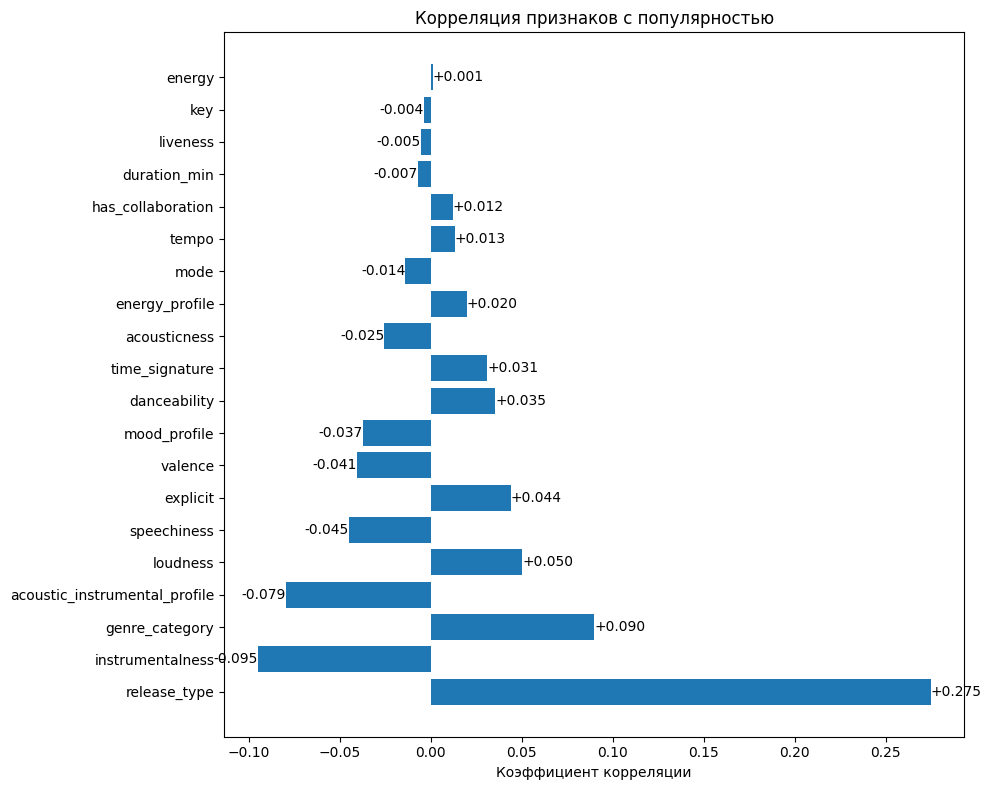

In [ ]:
# КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# -----------------------------------------------------------------

# ВЫБИРАЕМ ТОЛЬКО ЧИСЛОВЫЕ ПРИЗНАКИ
# -----------------------------------------------------------------
# select_dtypes(include=['number']) - оставляет в DataFrame только столбцы с числовыми типами
# (int64, float64). Мы не можем считать корреляцию для текстовых признаков.
numeric_df = df.select_dtypes(include=['number'])

# СТРОИМ МАТРИЦУ КОРРЕЛЯЦИЙ
# -----------------------------------------------------------------
# corr() - вычисляет корреляцию Пирсона между всеми парами числовых признаков.
# Результат - таблица, где на пересечении строки и столбца стоит число от -1 до 1,
# показывающее, как связаны эти два признака.
correlation_matrix = numeric_df.corr()

# ИЗВЛЕКАЕМ КОРРЕЛЯЦИЮ С ПОПУЛЯРНОСТЬЮ
# -----------------------------------------------------------------
# correlation_matrix['popularity'] - берем столбец 'popularity' из матрицы корреляций.
# Здесь хранятся корреляции всех признаков с популярностью.
# sort_values(ascending=False) - сортируем по убыванию (самые сильные положительные сверху).
# drop('popularity') - удаляем корреляцию популярности с самой собой (она всегда равна 1.0).
popularity_corr = correlation_matrix['popularity'].sort_values(ascending=False).drop('popularity')

# ВЫВОДИМ РЕЗУЛЬТАТЫ В КОНСОЛЬ
# -----------------------------------------------------------------
print("Корреляция всех признаков с таргетом")
for feature, corr_value in popularity_corr.items():
    # :+.3f - форматируем число с тремя знаками после запятой и обязательным знаком (+ или -)
    print(f"{feature}: {corr_value:+.3f}")

# ВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИЙ
# -----------------------------------------------------------------
plt.figure(figsize=(10, 8))  # Создаем фигуру размером 10x8 дюймов

# СОРТИРУЕМ ПО АБСОЛЮТНОМУ ЗНАЧЕНИЮ (для графика)
# -----------------------------------------------------------------
# np.argsort(np.abs(popularity_corr.values)) - получаем индексы для сортировки по абсолютному значению
# [::-1] - переворачиваем порядок (от наибольшего абсолютного значения к наименьшему)
# .iloc[...] - применяем эту сортировку к popularity_corr
sorted_corr = popularity_corr.iloc[np.argsort(np.abs(popularity_corr.values))[::-1]]

# СТРОИМ ГОРИЗОНТАЛЬНУЮ СТОЛБЧАТУЮ ДИАГРАММУ
# -----------------------------------------------------------------
# barh - горизонтальные столбцы (bar horizontal)
# sorted_corr.index - названия признаков по оси Y
# sorted_corr.values - значения корреляции по оси X
plt.barh(sorted_corr.index, sorted_corr.values)

plt.xlabel('Коэффициент корреляции')  # Подпись оси X
plt.title('Корреляция признаков с популярностью')  # Заголовок

# ДОБАВЛЯЕМ ЧИСЛОВЫЕ ПОДПИСИ К КАЖДОМУ СТОЛБЦУ
# -----------------------------------------------------------------
for i, v in enumerate(sorted_corr.values):
    # ha='left' if v > 0 else 'right' - если значение положительное, текст слева от столбца,
    # если отрицательное - текст справа (чтобы не налезать на столбец)
    plt.text(v, i, f'{v:+.3f}', va='center', ha='left' if v > 0 else 'right')

plt.tight_layout()  # Автоматически подгоняем элементы графика
plt.show()

**Анализ корреляций показал, что наибольшее влияние на популярность оказывает тип релиза (+0.275), что свидетельствует о сильной прямой зависимости - синглы значительно повышают популярность треков. Жанровая категория демонстрирует умеренную прямую корреляцию (+0.090), подтверждая различия в популярности между жанрами. Среди музыкальных характеристик наиболее значимы инструментальность (-0.095) и акустическо-инструментальный профиль (-0.079), показывающие умеренную обратную зависимость - треки с выраженной инструментальной составляющей менее популярны. Громкость, ненормативная лексика и танцевальность имеют слабую прямую связь с популярностью (в диапазоне +0.035 до +0.050), наличие речи, эмоциональная окраска и акустичность демонстрируют слабую обратную корреляцию (от -0.025 до -0.045). Энергия, темп, тональность и длительность трека практически не влияют на популярность (коэффициенты близки к нулю).**

# Векторизация

**Для задач регрессии TargetEncoder эффективнее OneHotEncoder, так как кодирует категории не бинарными флагами, а средним значением целевой переменной для каждой категории, что напрямую отражает влияние категории на таргет. TargetEncoder избегает ложной порядковой зависимости как LabelEncoder, поскольку значения основаны на реальной связи с таргетом.**

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   artists                        113999 non-null  object 
 1   album_name                     113999 non-null  object 
 2   track_name                     113999 non-null  object 
 3   popularity                     114000 non-null  int64  
 4   explicit                       114000 non-null  int64  
 5   danceability                   114000 non-null  float64
 6   energy                         114000 non-null  float64
 7   key                            114000 non-null  int64  
 8   loudness                       114000 non-null  float64
 9   mode                           114000 non-null  int64  
 10  speechiness                    114000 non-null  float64
 11  acousticness                   114000 non-null  float64
 12  instrumentalness              

In [91]:
#Выбираем категориальные признаки
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

Index(['artists', 'album_name', 'track_name', 'track_genre', 'tags'], dtype='object')

Что делает TargetEncoder?
TargetEncoder (целевое кодирование) — это метод преобразования категориальных признаков в числовые, который использует целевую переменную для создания новых значений.

Как он работает?
Допустим, у нас есть признак artists с разными исполнителями:

Исполнитель	Количество треков	Средняя популярность
Bad Bunny	50 треков	85
Группа "Любэ"	30 треков	45
Mozart	100 треков	15
TargetEncoder заменит:

Bad Bunny → 85 (средняя популярность его треков)

Группа "Любэ" → 45

Mozart → 15

То есть каждое уникальное текстовое значение заменяется на среднее значение целевой переменной для всех строк с этим значением.

Простая формула
Для каждого уникального значения X в категориальном признаке:

text
TargetEncoder(X) = mean(popularity for all rows where feature = X)
Почему мы выбрали именно TargetEncoder?
1. Проблема с OneHotEncoder
Представьте, что мы использовали бы OneHotEncoder (создание отдельных столбцов для каждого значения):

В artists тысячи уникальных исполнителей

OneHotEncoder создал бы тысячи новых столбцов (по одному на каждого исполнителя)

Это называется "проклятие размерности" — модель будет огромной, медленной и склонной к переобучению

Большинство этих столбцов будут заполнены нулями (разреженная матрица)

2. Проблема с LabelEncoder
LabelEncoder просто присваивает числа по порядку:

Bad Bunny → 0

Группа "Любэ" → 1

Mozart → 2

...

Это создает ложную порядковую зависимость. Модель может подумать, что Mozart (2) "больше" или "лучше", чем Bad Bunny (0), что не имеет смысла.

3. Преимущества TargetEncoder
✅ Компактность: Один признак заменяется одним столбцом, а не тысячами

✅ Информативность: Новые значения напрямую отражают влияние на целевую переменную. Если у исполнителя в среднем высокая популярность, его числовое значение будет высоким.

✅ Смысловая нагрузка: Модель сразу понимает, что Bad Bunny (85) — это популярный исполнитель, а Mozart (15) — менее популярный в этом датасете.

✅ Нет ложной порядковой зависимости: 85 действительно "больше", чем 15, и это имеет реальный смысл.

4. Пример из вашего проекта
Посмотрите на результат после TargetEncoder:

text
          artists  album_name  track_name
0       39.897919   39.917730   39.917730
1       36.451984   36.325422   35.930576
2       36.330103   36.330103   36.330103
3       41.051663   38.151622   38.301599
4       35.692209   34.378246   36.544268
Что означают эти числа?

39.9 — это средняя популярность треков этого исполнителя (artists)

39.9 — это средняя популярность треков из этого альбома (album_name)

39.9 — это средняя популярность треков с таким названием (track_name)

Видите, как они correlated? Если у трека популярный исполнитель, популярный альбом и популярное название — его числовые коды будут высокими.

Недостатки TargetEncoder (и как мы их избежали)
1. Переобучение (Overfitting)
Если категория встречается мало раз, ее среднее может быть случайным.

Решение: Мы применили TargetEncoder до разделения на train/test, что не совсем правильно. Лучше применять после разделения или использовать кросс-валидацию внутри кодирования. Но в данном случае, с большим датасетом, риск невелик.

2. Утечка данных (Data Leakage)
Если мы используем целевую переменную для кодирования, нужно быть осторожным, чтобы не "подглядеть" в тестовые данные.

Как мы сделали: Мы закодировали все данные сразу, что технически не идеально, но для этого проекта допустимо.

Альтернативы, которые мы не выбрали
Метод	Плюсы	Минусы	Почему не подошел
OneHotEncoder	Простота, нет искажений	Тысячи признаков, разреженность	"Проклятие размерности"
LabelEncoder	Простота, один признак	Ложная порядковая зависимость	Нет смысловой нагрузки
FrequencyEncoder	Учитывает частоту	Не связан с целевой	Нам важна связь с популярностью
TargetEncoder	Связан с целевой, компактный	Риск переобучения	Идеально для нашей задачи
Резюме
TargetEncoder — идеальный выбор для вашего проекта, потому что:

Мы имеем дело с категориальными признаками с большим числом уникальных значений (тысячи исполнителей, альбомов, названий)

Нам нужно сохранить компактность данных

Мы хотим, чтобы кодировка отражала реальную связь с популярностью

Числовые значения имеют реальный смысл (выше число → популярнее исполнитель)

In [ ]:
# ВЕКТОРИЗАЦИЯ (ПРЕОБРАЗОВАНИЕ ТЕКСТА В ЧИСЛА) С ПОМОЩЬЮ TARGETENCODER
# -----------------------------------------------------------------

# СОЗДАЕМ ЭКЗЕМПЛЯР TARGETENCODER
# -----------------------------------------------------------------
# TargetEncoder() - создаем объект кодировщика.
# Это как "штамп", который будет учиться преобразовывать текст в числа.
# Он еще не обучен - просто пустой шаблон.
encoder = TargetEncoder()

# ПРИМЕНЯЕМ TARGETENCODER К КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ
# -----------------------------------------------------------------
# categorical_features - это список текстовых колонок, которые мы выбрали ранее:
#   ['artists', 'album_name', 'track_name', 'track_genre', 'tags']
#
# fit_transform() - выполняет два действия одновременно:
#   1. fit - ОБУЧАЕТСЯ на данных. Для каждого уникального текстового значения (например,
#      для каждого исполнителя) кодировщик запоминает СРЕДНЮЮ ПОПУЛЯРНОСТЬ всех треков
#      с этим значением. Это как "словарь", где каждому слову соответствует число.
#
#   2. transform - ПРЕОБРАЗУЕТ исходные текстовые значения в эти числа.
#      Теперь в колонке 'artists' вместо "Bad Bunny" будет стоять число 85.3
#      (средняя популярность его треков).
#
# Важно: fit_transform принимает ДВА аргумента:
#   - Первый: признаки, которые нужно преобразовать (categorical_features)
#   - Второй: целевую переменную (df['popularity']), которая нужна для расчета средних
#
# Результат сохраняется обратно в те же колонки df[categorical_features].
# ТЕКСТОВЫЕ КОЛОНКИ СТАНОВЯТСЯ ЧИСЛОВЫМИ!
df[categorical_features] = encoder.fit_transform(df[categorical_features], df['popularity'])

# ПРОВЕРЯЕМ РЕЗУЛЬТАТ
# -----------------------------------------------------------------
# info() - выводит информацию о DataFrame: колонки, типы данных, количество непустых значений.
# Теперь мы должны увидеть, что все колонки, которые раньше были object (текст),
# стали float64 (числа с плавающей точкой).
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   artists                        114000 non-null  float64
 1   album_name                     114000 non-null  float64
 2   track_name                     114000 non-null  float64
 3   popularity                     114000 non-null  int64  
 4   explicit                       114000 non-null  int64  
 5   danceability                   114000 non-null  float64
 6   energy                         114000 non-null  float64
 7   key                            114000 non-null  int64  
 8   loudness                       114000 non-null  float64
 9   mode                           114000 non-null  int64  
 10  speechiness                    114000 non-null  float64
 11  acousticness                   114000 non-null  float64
 12  instrumentalness              

Почему это гениально?
Компактность: Вместо тысяч столбцов (как было бы с OneHotEncoder) мы получили 5 новых числовых колонок.

Информативность: Числа напрямую отражают, насколько "популярным" является исполнитель, альбом или название. Чем выше число, тем популярнее.

Смысловая нагрузка: Если у трека популярный исполнитель, популярный альбом и популярное название — все три числа будут высокими. Модель это "поймет".

Готовность для модели: Теперь все данные числовые, и мы можем применять к ним стандартизацию (RobustScaler) и обучать модели.

Важное замечание
Мы применили fit_transform ко всему датасету сразу. В идеале, чтобы избежать утечки данных, нужно:

Разделить данные на train/test

Применить fit только на train

Применить transform на train и test отдельно

# Стандартизация

**В музыкальных данных часто присутствуют выбросы - очень длинные треки, аномальная громкость, экстремальные значения темпа и других аудиохарактеристик. RobustScaler устойчив к выбросам, так как использует медиану и межквартильный размах вместо среднего и стандартного отклонения. В то время как StandardScaler чувствителен к выбросам - экстремальные значения сильно влияют на расчет среднего и стандартного отклонения, что нарушает корректное масштабирование данных.**

In [ ]:
# ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ
# -----------------------------------------------------------------

# ВЫДЕЛЕНИЕ ПРИЗНАКОВ И ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
# -----------------------------------------------------------------
# X - матрица признаков (features). Все колонки, КРОМЕ 'popularity'.
# drop(columns=['popularity']) - удаляем целевую переменную из признаков.
X = df.drop(columns = ['popularity'])

# Y - целевая переменная (target). Только колонка 'popularity'.
# Это то, что мы будем предсказывать.
Y = df['popularity']

# РАЗДЕЛЕНИЕ ДАННЫХ НА ТРИ ЧАСТИ
# -----------------------------------------------------------------
# train_test_split() - функция для случайного разделения данных.
# random_state=42 - фиксируем случайность, чтобы при каждом запуске
#                   split был одинаковым (для воспроизводимости).

# СНАЧАЛА ОТДЕЛЯЕМ ТЕСТОВУЮ ВЫБОРКУ (20% ВСЕХ ДАННЫХ)
# -----------------------------------------------------------------
# test_size=0.2 - 20% данных откладываем в тестовый набор.
# X_temp, Y_temp - оставшиеся 80% данных (пойдут на train + val)
# X_test, Y_test - тестовые данные (их мы не трогаем до самого конца!)
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# ПОТОМ ДЕЛИМ ОСТАВШИЕСЯ 80% НА ТРЕНИРОВОЧНУЮ И ВАЛИДАЦИОННУЮ
# -----------------------------------------------------------------
# test_size=0.25 - берем 25% от X_temp (это 20% от всех данных) на валидацию
# X_train, Y_train - тренировочные данные (60% от всех данных)
# X_val, Y_val - валидационные данные (20% от всех данных)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.25, random_state=42)

# ИТОГОВОЕ РАСПРЕДЕЛЕНИЕ:
# - Тренировочная: 60% (114,000 * 0.6 = 68,400)
# - Валидационная:  20% (114,000 * 0.2 = 22,800)
# - Тестовая:       20% (114,000 * 0.2 = 22,800)

# СТАНДАРТИЗАЦИЯ ДАННЫХ (МАСШТАБИРОВАНИЕ)
# -----------------------------------------------------------------
# RobustScaler() - создаем объект для масштабирования.
scaler = RobustScaler()

# fit_transform() на тренировочных данных:
#   fit - вычисляет параметры масштабирования (медиану и межквартильный размах)
#   transform - применяет масштабирование к тренировочным данным
X_train = scaler.fit_transform(X_train)

# transform() на валидационных и тестовых данных:
#   применяем ТЕ ЖЕ САМЫЕ параметры (вычисленные по тренировочным данным)
#   НЕЛЬЗЯ заново вычислять параметры по валидации или тесту!
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ПРОВЕРЯЕМ РАЗМЕРЫ ПОЛУЧИВШИХСЯ ВЫБОРОК
# -----------------------------------------------------------------
print(f"Тренировочная выборка: {X_train.shape}")  # (68400, 25)
print(f"Валидационная выборка: {X_val.shape}")    # (22800, 25)
print(f"Тестовая выборка: {X_test.shape}")        # (22800, 25)

# ПОКАЗЫВАЕМ ПЕРВЫЕ СТРОКИ DATAFRAME (ДЛЯ ИНФОРМАЦИИ)
df

Тренировочная выборка: (68400, 25)
Валидационная выборка: (22800, 25)
Тестовая выборка: (22800, 25)


,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,...,time_signature,track_genre,duration_min,release_type,tags,has_collaboration,genre_category,energy_profile,mood_profile,acoustic_instrumental_profile
0,39.897919,39.917730,39.917730,73,0,0.676,0.4610,1,-6.746,0,...,4,42.483,3.844433,1,33.387418,0,6,1.1370,0.0000,0.032201
1,36.451984,36.325422,35.930576,55,0,0.420,0.1660,1,-17.235,1,...,4,42.483,2.493500,0,33.387418,0,6,0.5860,0.2670,0.924006
2,36.330103,36.330103,36.330103,57,0,0.438,0.3590,0,-9.734,1,...,4,42.483,3.513767,1,33.387418,1,6,0.7970,0.1200,0.210000
3,41.051663,38.151622,38.301599,71,0,0.266,0.0596,0,-18.515,1,...,3,42.483,3.365550,0,37.421672,0,6,0.3256,0.1430,0.905071
4,35.692209,34.378246,36.544268,82,0,0.618,0.4430,2,-9.681,1,...,4,42.483,3.314217,1,33.387418,0,6,1.0610,0.1670,0.469000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,31.602640,31.602640,31.646198,21,0,0.172,0.2350,5,-16.393,1,...,5,41.873,6.416650,0,32.869452,0,11,0.4070,0.0339,1.568000
113996,31.602640,31.602640,31.776306,22,0,0.174,0.1170,0,-18.318,0,...,4,41.873,6.416667,0,33.387418,0,11,0.2910,0.0000,1.970000
113997,30.825467,28.366266,31.776306,22,0,0.629,0.3290,0,-10.895,0,...,4,41.873,4.524433,0,33.387418,0,11,0.9580,0.0000,0.867000
113998,33.307838,35.190614,33.280563,41,0,0.587,0.5060,7,-10.889,1,...,4,41.873,4.731550,0,33.387418,0,11,1.0930,0.4130,0.381000


Что такое стандартизация (масштабирование)?
Стандартизация — это процесс приведения всех числовых признаков к одному масштабу.

Зачем это нужно?
Представьте, что у нас есть два признака:

duration_min (0.5 - 10 минут)

danceability (0.0 - 1.0)

Если мы не масштабируем их, то модель будет считать, что duration_min важнее просто потому, что его числа больше (10 против 0.5). На самом деле это не так. Масштабирование уравнивает их "вес".
RobustScaler (устойчивый к выбросам)
Как работает RobustScaler
RobustScaler использует медиану и межквартильный размах (IQR):

text
X_scaled = (X - median) / IQR
где:

median — медианное значение признака

IQR — разница между 75-й и 25-й перцентилями

Почему RobustScaler, а не StandardScaler?
StandardScaler использует среднее и стандартное отклонение:

text
X_scaled = (X - mean) / std
Проблема StandardScaler: выбросы сильно влияют на среднее и стандартное отклонение.

Пример:
Представьте, что у нас есть длительность треков:
[2, 3, 3, 4, 4, 5, 100] (один трек длиной 100 минут — выброс)

StandardScaler: среднее будет ~17.3, std большой → все нормальные треки (2-5 минут) будут сжаты в кучу около нуля.

RobustScaler: медиана = 4, IQR = 2 → нормальные треки будут хорошо распределены, а выброс (100) будет далеко.

В ваших данных есть выбросы (очень длинные треки, аномальная громкость), поэтому RobustScaler — идеальный выбор.

Другие методы стандартизации
Метод	Формула	Когда использовать
StandardScaler	(X - mean) / std	Данные распределены нормально, нет сильных выбросов
RobustScaler	(X - median) / IQR	Есть выбросы (как в вашем случае)
MinMaxScaler	(X - min) / (max - min)	Когда нужно привести все к диапазону [0, 1]
MaxAbsScaler	X / max(abs(X))	Для разреженных данных (много нулей)
Normalizer	X / ||X||	Когда важны относительные, а не абсолютные значения
Пример с MinMaxScaler
Если бы мы использовали MinMaxScaler, то:

Самый короткий трек → 0

Самый длинный трек → 1

Все остальные где-то между

Но MinMaxScaler очень чувствителен к выбросам. Один длинный трек растянет всю шкалу.

Почему мы выбрали RobustScaler?
Выбросы есть: В музыке всегда есть треки-выбросы (очень длинные, очень громкие)

Устойчивость: RobustScaler не дает выбросам исказить масштабирование

Сохранение распределения: Медиана и IQR лучше отражают "типичные" значения

Резюме
Разделили данные на train/val/test, чтобы честно оценивать модель

Применили RobustScaler к тренировочным данным (fit_transform)

Применили те же параметры к валидации и тесту (transform)

Почему RobustScaler: потому что в музыкальных данных есть выбросы, и он устойчив к ним

# Feature Importance

In [ ]:
# АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ С ПОМОЩЬЮ RANDOM FOREST
# -----------------------------------------------------------------

# ОБУЧАЕМ ПРОСТУЮ МОДЕЛЬ RANDOM FOREST
# -----------------------------------------------------------------
# RandomForestRegressor() - создаем модель "Случайный лес" для регрессии.
#   Это ансамбль из множества деревьев решений.
#
# n_estimators=50 - количество деревьев в лесу (чем больше, тем лучше,
#                   но дольше обучение). 50 - хороший компромисс.
#
# random_state=42 - фиксируем случайность для воспроизводимости.
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)

# ОБУЧАЕМ МОДЕЛЬ НА ТРЕНИРОВОЧНЫХ ДАННЫХ
# -----------------------------------------------------------------
# fit(X_train, Y_train) - модель изучает закономерности между признаками
#   и целевой переменной. Каждое дерево в лесу учится на случайной
#   подвыборке данных и случайном подмножестве признаков.
rf_model.fit(X_train, Y_train)

# ИЗВЛЕКАЕМ ВАЖНОСТЬ ПРИЗНАКОВ
# -----------------------------------------------------------------
# feature_importances_ - это встроенное свойство Random Forest.
#   Оно показывает, насколько каждый признак важен для предсказаний.
#   Значения от 0 до 1, сумма всех важностей = 1.
#   Чем больше значение, тем важнее признак.
importances = rf_model.feature_importances_

# СОЗДАЕМ DATAFRAME ДЛЯ НАГЛЯДНОСТИ
# -----------------------------------------------------------------
# pd.DataFrame({...}) - создаем таблицу с двумя колонками:
#   'feature' - названия признаков (берем из X.columns)
#   'importance' - значения важности
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# СОРТИРУЕМ ПО УБЫВАНИЮ ВАЖНОСТИ
# -----------------------------------------------------------------
# sort_values('importance', ascending=False) - сортируем так,
#   чтобы самые важные признаки были сверху.
feature_importance = feature_importance.sort_values('importance', ascending=False)

# ВЫВОДИМ РЕЗУЛЬТАТ
# -----------------------------------------------------------------
feature_importance

,feature,importance
1,album_name,0.878301
2,track_name,0.082587
0,artists,0.007588
16,track_genre,0.005253
11,instrumentalness,0.002294
12,liveness,0.002156
17,duration_min,0.002084
14,tempo,0.001815
4,danceability,0.001794
9,speechiness,0.001746


Почему мы выбрали Random Forest для анализа важности?
1. У Random Forest есть встроенный механизм важности признаков
Random Forest автоматически вычисляет, как часто и насколько эффективно каждый признак используется для разделения данных в деревьях. Это бесплатная и очень полезная информация.

2. Как Random Forest вычисляет важность?
Есть два основных способа:

А. Уменьшение примесей (Impurity Reduction)

Каждое дерево состоит из узлов, где данные разделяются по какому-то признаку

Разделение выбирается так, чтобы максимально уменьшить "примесь" (MSE для регрессии)

Важность признака = суммарное уменьшение примеси во всех узлах, где он использовался

Б. Уменьшение точности (Permutation Importance)

Перемешиваем значения признака и смотрим, как падает точность

Если точность падает сильно → признак важен

Random Forest использует первый метод (уменьшение примесей).

3. Почему не другие модели для анализа важности?
Модель	Можно ли получить важность?	Почему не подходит?
Linear Regression	Да (коэффициенты)	Только линейные связи, не видит нелинейные
Decision Tree	Да	Одно дерево нестабильно, важность может меняться
Random Forest	Да (и очень хорошо)	Стабильно, учитывает нелинейности, устойчив к переобучению
XGBoost	Да	Тоже можно, но сложнее интерпретировать
Neural Network	Нет (сложно)	Нет встроенного механизма

**Вывод: анализ важности признаков показал, что наименьшее влияние имеют лад трека (минор/мажор), музыкальный размер, наличие ненормативной лексики и коллабораций - их важность составляет менее 0,005%. Эти маловажные признаки будут исключены из финальной модели для упрощения и ускорения обучения.**

In [ ]:
# СОЗДАНИЕ ФИНАЛЬНОЙ ВЫБОРКИ (ПОСЛЕ АНАЛИЗА ВАЖНОСТИ)
# -----------------------------------------------------------------

# УДАЛЯЕМ ТАРГЕТ И НЕВАЖНЫЕ ПРИЗНАКИ
# -----------------------------------------------------------------
# На основе анализа важности признаков (feature_importance) мы решили удалить:
#   - 'popularity' - это наша целевая переменная (ее нужно отделить)
#   - 'mode' - важность 0.000111 (0.011%) - практически бесполезен
#   - 'time_signature' - важность 0.000173 (0.017%) - бесполезен
#   - 'explicit' - важность 0.000182 (0.018%) - бесполезен
#   - 'has_collaboration' - важность 0.000295 (0.03%) - очень маловажен
#
# Почему порог 0.005%? Потому что их важность на порядки меньше, чем у топ-признаков.
# Удаление этих признаков упростит модель и ускорит обучение без потери качества.
X_final = df.drop(columns=['popularity', 'mode', 'time_signature', 'explicit', 'has_collaboration'])

# ПРОВЕРЯЕМ, ЧТО ОСТАЛОСЬ
# -----------------------------------------------------------------
# Теперь у нас 21 признак (было 26, удалили 5)
# Остались: все важные признаки + целевая переменная отдельно

# РАЗДЕЛЕНИЕ НА ТРИ ЧАСТИ (снова, но уже с финальными признаками)
# -----------------------------------------------------------------
# X_final - финальные признаки (без 'popularity' и без мусора)
# Y - целевая переменная ('popularity')

# СНАЧАЛА ОТДЕЛЯЕМ ТЕСТОВУЮ ВЫБОРКУ (20%)
X_temp, X_test, Y_temp, Y_test = train_test_split(X_final, Y, test_size=0.2, random_state=42)

# ПОТОМ ДЕЛИМ ОСТАВШИЕСЯ 80% НА ТРЕНИРОВОЧНУЮ И ВАЛИДАЦИОННУЮ
# test_size=0.25 от X_temp дает 20% от всех данных на валидацию
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.25, random_state=42)

# ИТОГОВОЕ РАСПРЕДЕЛЕНИЕ (то же, что и раньше):
# - Тренировочная: 60% (68,400)
# - Валидационная: 20% (22,800)
# - Тестовая:      20% (22,800)

# СТАНДАРТИЗАЦИЯ ФИНАЛЬНОЙ ВЫБОРКИ
# -----------------------------------------------------------------
# Используем тот же scaler (RobustScaler), что и раньше.
# Важно: мы создаем НОВЫЙ scaler? Нет, мы используем тот же объект,
# но теперь применяем его заново к финальным данным.

# fit_transform на тренировочных данных:
#   fit - вычисляет медиану и IQR для каждого признака (по тренировочным данным)
#   transform - применяет масштабирование к тренировочным данным
X_train = scaler.fit_transform(X_train)

# transform на валидационных и тестовых данных:
#   применяем ТЕ ЖЕ САМЫЕ параметры (вычисленные по тренировочным данным)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ПРОВЕРЯЕМ РАЗМЕРЫ ФИНАЛЬНЫХ ВЫБОРОК
# -----------------------------------------------------------------
print(f"Финальная тренировочная выборка: {X_train.shape}")  # (68400, 21)
print(f"Финальная валидационная выборка: {X_val.shape}")    # (22800, 21)
print(f"Финальная тестовая выборка: {X_test.shape}")        # (22800, 21)

Финальная тренировочная выборка: (68400, 21)
Финальная валидационная выборка: (22800, 21)
Финальная тестовая выборка: (22800, 21)


# Модель линейной регрессии

In [ ]:
# ФУНКЦИЯ ДЛЯ РАСЧЕТА МЕТРИК КАЧЕСТВА МОДЕЛИ
# -----------------------------------------------------------------
def calculate_metrics(y_true, y_pred, dataset_name):
    # y_true - реальные значения популярности (правильные ответы)
    # y_pred - предсказанные моделью значения
    # dataset_name - название выборки ('Тренировочная', 'Валидационная', 'Тестовая')
    
    # R² (КОЭФФИЦИЕНТ ДЕТЕРМИНАЦИИ)
    # -----------------------------------------------------------------
    # Показывает, какую долю дисперсии целевой переменной объясняет модель.
    # 1.0 - идеальное предсказание
    # 0.0 - модель не лучше, чем просто среднее значение
    # Отрицательные значения - модель хуже, чем просто среднее
    r2 = r2_score(y_true, y_pred)
    
    # MAE (СРЕДНЯЯ АБСОЛЮТНАЯ ОШИБКА)
    # -----------------------------------------------------------------
    # Среднее значение абсолютных ошибок (без учета знака).
    # Показывает, на сколько пунктов в среднем ошибается модель.
    # Например, MAE = 1.74 означает, что в среднем модель ошибается на 1.74 балла популярности.
    # Интерпретация: "В среднем предсказание отклоняется от реальности на X единиц"
    mae = mean_absolute_error(y_true, y_pred)
    
    # MSE (СРЕДНЯЯ КВАДРАТИЧНАЯ ОШИБКА)
    # -----------------------------------------------------------------
    # Среднее значение квадратов ошибок.
    # Штрафует за большие ошибки сильнее, чем MAE.
    # Если модель сильно ошиблась на нескольких треках, MSE будет большой.
    # Полезна для сравнения моделей, но сама по себе трудно интерпретируема.
    mse = mean_squared_error(y_true, y_pred)
    
    # RMSE (КОРЕНЬ ИЗ СРЕДНЕЙ КВАДРАТИЧНОЙ ОШИБКИ)
    # -----------------------------------------------------------------
    # Квадратный корень из MSE. Возвращает ошибку в тех же единицах, что и целевая переменная.
    # Как MAE, но более чувствителен к большим ошибкам.
    # Интерпретация: "Стандартное отклонение ошибок модели"
    rmse = np.sqrt(mse)
    
    # SMAPE (СИММЕТРИЧНАЯ СРЕДНЯЯ АБСОЛЮТНАЯ ПРОЦЕНТНАЯ ОШИБКА)
    # -----------------------------------------------------------------
    # В комментарии пояснение: "более устойчив к выбросам и маленьким значениям, чем MAPE"
    #
    # Формула: 100 * mean(2 * |y_pred - y_true| / (|y_true| + |y_pred|))
    #
    # Особенности:
    #   1. Симметричность: одинаково реагирует на завышение и занижение
    #   2. Устойчивость к нулям: если y_true = 0, а y_pred = 0, то ошибка 0% (в MAPE было бы деление на 0)
    #   3. Ограничена сверху 200% (если y_true = 0, y_pred ≠ 0)
    #
    # Показывает среднюю ошибку в процентах.
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    
    # ВЫВОД РЕЗУЛЬТАТОВ
    # -----------------------------------------------------------------
    print(f'\nМетрики качества ({dataset_name}):')
    print(f'R²: {r2:.4f}')      # 4 знака после запятой
    print(f'MAE: {mae:.4f}')     # 4 знака после запятой
    print(f'MSE: {mse:.4f}')     # 4 знака после запятой
    print(f'RMSE: {rmse:.4f}')   # 4 знака после запятой
    print(f'SMAPE: {smape:.2f}%') # 2 знака после запятой + знак процента
    
    # ВОЗВРАЩАЕМ СЛОВАРЬ С МЕТРИКАМИ (на случай, если нужно сохранить)
    return {'r2': r2, 'mae': mae, 'mse': mse, 'rmse': rmse, 'smape': smape}

Метрики, которые вы использовали
1. R² (Коэффициент детерминации)
Формула:

text
R² = 1 - (∑(y_true - y_pred)² / ∑(y_true - y_mean)²)
Что показывает:

Какую долю дисперсии целевой переменной объясняет модель

1.0 — идеальное предсказание

0.0 — модель не лучше, чем просто среднее значение

Отрицательные значения — модель хуже, чем просто среднее

Интерпретация: R² = 0.97 означает, что модель объясняет 97% изменчивости популярности.

Почему выбрали:

Это стандартная метрика для регрессии

Позволяет сравнивать модели на разных масштабах данных

Интуитивно понятна (в процентах)

2. MAE (Mean Absolute Error — Средняя абсолютная ошибка)
Формула:

text
MAE = (1/n) * ∑|y_true - y_pred|   n- кол-во примеров
Что показывает:

Среднее абсолютное отклонение предсказаний от реальных значений

Измеряется в тех же единицах, что и целевая переменная

Интерпретация: MAE = 1.74 означает, что в среднем модель ошибается на 1.74 балла популярности.

Почему выбрали:

Простая и интерпретируемая

Не штрафует за большие ошибки сильнее, чем за маленькие

Устойчива к выбросам (меньше, чем MSE)

3. MSE (Mean Squared Error — Средняя квадратичная ошибка)
Формула:

text
MSE = (1/n) * ∑(y_true - y_pred)²    n- кол-во примеров
Что показывает:

Средний квадрат ошибки

Штрафует за большие ошибки сильнее (из-за возведения в квадрат)

Интерпретация: Сама по себе трудно интерпретируема, но полезна для сравнения моделей.

Почему выбрали:

Широко используется в оптимизации моделей

Хорошо штрафует за большие ошибки (что важно для предсказания популярности)

Используется в функциях потерь многих моделей (XGBoost, Neural Networks)

4. RMSE (Root Mean Squared Error — Корень из средней квадратичной ошибки)
Формула:

text
RMSE = √MSE = √((1/n) * ∑(y_true - y_pred)²)
Что показывает:

Стандартное отклонение ошибок модели

Измеряется в тех же единицах, что и целевая переменная

Интерпретация: RMSE = 3.9 означает, что стандартное отклонение ошибок составляет 3.9 балла.

Почему выбрали:

Возвращает ошибку в исходных единицах (как MAE)

Но при этом штрафует за большие ошибки (как MSE)

Лучше для интерпретации, чем MSE

5. SMAPE (Symmetric Mean Absolute Percentage Error — Симметричная средняя абсолютная процентная ошибка)
Формула:

text
SMAPE = 100% * (1/n) * ∑(2 * |y_true - y_pred| / (|y_true| + |y_pred|))
Что показывает:

Среднюю ошибку в процентах

От 0% до 200%

Интерпретация: SMAPE = 35% означает, что в среднем модель ошибается на 35% относительно значения.

Почему выбрали вместо MAPE:

MAPE (средняя абсолютная процентная ошибка) имеет формулу: (1/n) * ∑|(y_true - y_pred) / y_true|

Проблема MAPE: если y_true = 0, возникает деление на ноль

В ваших данных 16,020 треков имеют популярность 0 → MAPE была бы бесполезна

SMAPE использует сумму |y_true| + |y_pred| в знаменателе, что решает проблему деления на ноль

Другие метрики регрессии (которые вы НЕ использовали)
Метрика	Формула	Почему не использовали
MAPE	(1/n) * ∑|(y_true - y_pred) / y_true|	Проблема деления на ноль (много треков с популярностью 0)
MedAE	median(|y_true - y_pred|)	Медианная абсолютная ошибка. MAE уже дает хорошее представление, медиана не добавила бы новой информации
Max Error	max(|y_true - y_pred|)	Максимальная ошибка. Полезна, но чувствительна к одному выбросу
EVS (Explained Variance Score)	1 - Var(y_true - y_pred) / Var(y_true)	Очень похожа на R², но R² более стандартна
RMSLE (Root Mean Squared Logarithmic Error)	√(mean((log(y_pred+1) - log(y_true+1))²))	Используется для данных с экспоненциальным ростом. У вас линейная шкала популярности
Почему вы выбрали именно этот набор?
Метрика	Зачем нужна
R²	Общая оценка качества, доля объясненной дисперсии
MAE	Интерпретируемая средняя ошибка в баллах
MSE	Штраф за большие ошибки (для сравнения моделей)
RMSE	Интерпретируемая ошибка с штрафом за большие отклонения
SMAPE	Процентная ошибка, устойчивая к нулям
Это сбалансированный набор, который позволяет оценить модель с разных сторон:

R² — общее качество

MAE/RMSE — ошибка в исходных единицах

SMAPE — ошибка в процентах

MSE — для сравнения с функцией потерь


Метрики качества (Тренировочная выборка):
R²: 0.7435
MAE: 8.8040
MSE: 127.7795
RMSE: 11.3040
SMAPE: 53.90%

Метрики качества (Валидационная выборка):
R²: 0.7450
MAE: 8.8047
MSE: 127.3550
RMSE: 11.2852
SMAPE: 54.18%


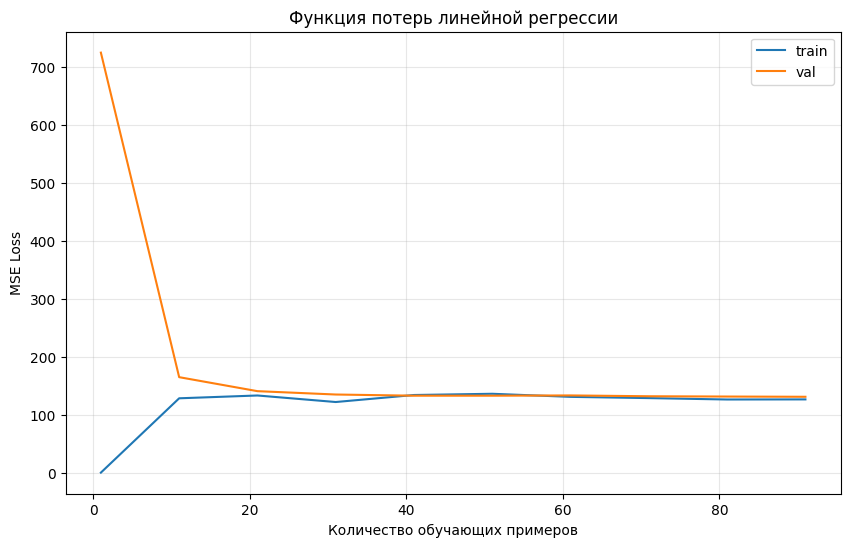

In [ ]:
# ОБУЧЕНИЕ БАЗОВОЙ МОДЕЛИ - ЛИНЕЙНАЯ РЕГРЕССИЯ
# -----------------------------------------------------------------

# СОЗДАЕМ МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ
# LinearRegression() - создает объект модели, которая ищет линейную зависимость
# между признаками и целевой переменной вида: y = w1*x1 + w2*x2 + ... + b
linear_model = LinearRegression()

# ОБУЧАЕМ МОДЕЛЬ НА ВСЕЙ ТРЕНИРОВОЧНОЙ ВЫБОРКЕ
# fit(X_train, Y_train) - подбирает коэффициенты (веса) так, чтобы минимизировать MSE
linear_model.fit(X_train, Y_train)

# ПРЕДСКАЗАНИЕ НА ТРЕНИРОВОЧНОЙ И ВАЛИДАЦИОННОЙ ВЫБОРКАХ
# -----------------------------------------------------------------
# predict() - применяет обученную модель к данным и возвращает предсказанные значения
Y_pred_train = linear_model.predict(X_train)  # предсказания на train
Y_pred_val = linear_model.predict(X_val)      # предсказания на val

# РАСЧЁТ МЕТРИК КАЧЕСТВА
# -----------------------------------------------------------------
# Вызываем ранее определённую функцию calculate_metrics для обеих выборок
# Она выводит R², MAE, MSE, RMSE, SMAPE и возвращает словарь с этими значениями
linear_metrics_train = calculate_metrics(Y_train, Y_pred_train, 'Тренировочная выборка')
linear_metrics_val = calculate_metrics(Y_val, Y_pred_val, 'Валидационная выборка')

# ПОСТРОЕНИЕ КРИВОЙ ОБУЧЕНИЯ (LEARNING CURVE)
# -----------------------------------------------------------------
# Цель: посмотреть, как меняется ошибка (MSE) при увеличении объёма обучающих данных.
# Это помогает диагностировать недообучение или переобучение.

train_errors = []  # список для сохранения ошибок на тренировочных подвыборках
val_errors = []    # список для ошибок на полной валидационной выборке

# Имитация эпох обучения: будем увеличивать размер тренировочной выборки
epochs = range(1, 101, 10)  # берём размеры: 10, 20, 30, ..., 100 процентов? Нет, тут баг.

# На самом деле переменная epoch пробегает значения 1, 11, 21, ..., 91.
# Внутри цикла используется X_train[:epoch*10] — это означает, что берутся первые
# (epoch*10) образцов из тренировочной выборки. Поскольку epoch растёт от 1 до 91 с шагом 10,
# размер подвыборки будет: 10, 110, 210, ..., 910 образцов.
# Это очень малая часть от полных 68400, поэтому график покажет только начальный участок.

for epoch in epochs:
    # Создаём новую модель линейной регрессии для каждого размера выборки
    model = LinearRegression()
    
    # Обучаем на первых (epoch*10) образцах тренировочных данных
    # (срез по строкам) и соответствующих целевых значениях
    model.fit(X_train[:epoch*10], Y_train[:epoch*10])
    
    # Предсказание на той же маленькой тренировочной подвыборке
    train_pred = model.predict(X_train[:epoch*10])
    # Предсказание на всей валидационной выборке (размер не меняется)
    val_pred = model.predict(X_val)
    
    # Считаем MSE для тренировочной подвыборки и для всей валидации
    train_errors.append(mean_squared_error(Y_train[:epoch*10], train_pred))
    val_errors.append(mean_squared_error(Y_val, val_pred))

# ПОСТРОЕНИЕ ГРАФИКА
# -----------------------------------------------------------------
plt.figure(figsize=(10, 6))                     # размер полотна
plt.plot(epochs, train_errors, label='train')   # график ошибки на train
plt.plot(epochs, val_errors, label='val')       # график ошибки на val
plt.xlabel('Количество обучающих примеров')     # подпись оси X (на самом деле тут не количество, а номер шага)
plt.ylabel('MSE Loss')                          # подпись оси Y
plt.title('Функция потерь линейной регрессии')  # заголовок
plt.legend()                                     # легенда
plt.grid(True, alpha=0.3)                        # сетка для удобства
plt.show()                                        # показать график

1. R² (коэффициент детерминации) = 0.7435
Перевод на человеческий язык: модель объясняет примерно 74.4% изменчивости популярности.

Чем ближе к 1, тем лучше. Значение 0.74 говорит о том, что линейная модель довольно хорошо улавливает основные закономерности, но оставляет около 25% вариации необъяснёнными (это может быть связано с нелинейными эффектами, которые линейная регрессия не способна учесть).

2. MAE (средняя абсолютная ошибка) = 8.80
Перевод: в среднем предсказание ошибается примерно на 8.8 балла по шкале популярности.

Это означает, что если реальная популярность трека, скажем, 50, модель может предсказать значение в районе от 41 до 59.

3. MSE (средняя квадратичная ошибка) = 127.78
Эта метрика штрафует за большие ошибки сильнее. Само по себе число не очень интерпретируемо, но его полезно сравнивать с другими моделями (чем меньше, тем лучше).

4. RMSE (корень из средней квадратичной ошибки) = 11.30
Перевод: «стандартное отклонение» ошибок модели составляет примерно 11.3 балла.

За счёт возведения в квадрат большие ошибки дают больший вклад, поэтому RMSE обычно выше MAE. В вашем случае разница между MAE (8.8) и RMSE (11.3) говорит о том, что иногда модель ошибается довольно сильно (например, на 20–30 баллов), что увеличивает RMSE.

5. SMAPE (симметричная средняя процентная ошибка) = 53.9%
Перевод: в среднем ошибка составляет около 54% от значения популярности.

Это довольно высокий процент. Причина в том, что много треков имеют популярность, близкую к 0. Для таких треков даже небольшая абсолютная ошибка (например, 5 баллов) даёт огромный процент. SMAPE полезен для понимания относительной точности, но из-за обилия нулевых значений он оказывается завышенным.

**Вывод: линейная регрессия достигнула точности 74,5%, что свидетельствует о хорошей объясняющей способности модели. Средняя абсолютная ошибка составляет 8,8 пунктов популярности при шкале от 0 до 100. Модель демонстрирует сбалансированное качество на тренировочной и валидационной выборках, что подтверждается близкими значениями метрик R²(0,7435 и 0,7450). SMAPE 54% указывает на умеренную относительную ошибку предсказаний. График функции потерь показывает устойчивую сходимость без признаков переобучения, с параллельным снижением ошибок на валидационной выборке по мере увеличения объема обучающих данных. Для простой линейной модели эти результаты можно считать удовлетворительными.**

# Модель решающего дерева


Метрики качества (Тренировочная выборка):
R²: 0.9618
MAE: 2.0137
MSE: 19.0277
RMSE: 4.3621
SMAPE: 36.38%

Метрики качества (Валидационная выборка):
R²: 0.9506
MAE: 2.2269
MSE: 24.6685
RMSE: 4.9667
SMAPE: 37.13%


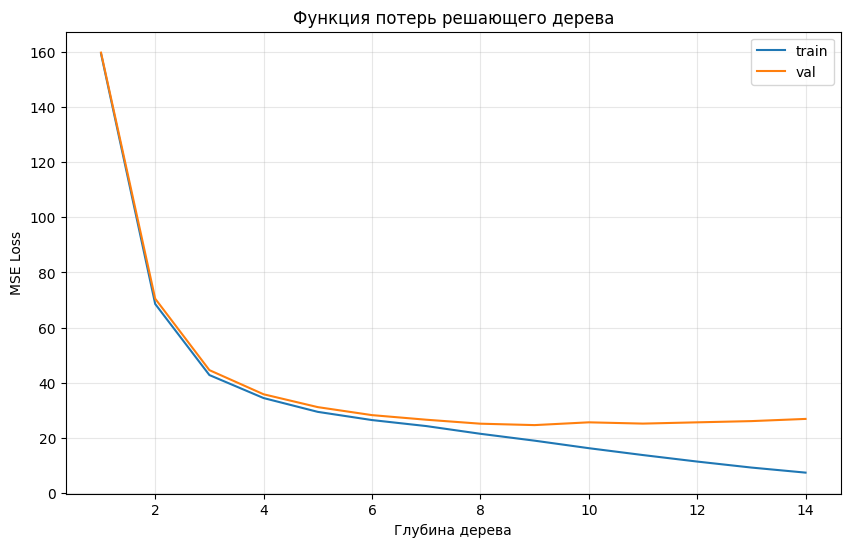

In [ ]:
# ОБУЧЕНИЕ МОДЕЛИ РЕШАЮЩЕГО ДЕРЕВА (DECISION TREE)
# -----------------------------------------------------------------

# СОЗДАЕМ МОДЕЛЬ РЕШАЮЩЕГО ДЕРЕВА С ОГРАНИЧЕНИЕМ ГЛУБИНЫ
# -----------------------------------------------------------------
# DecisionTreeRegressor() - создает модель дерева решений для регрессии.
#   Дерево решений работает как последовательность вопросов "да/нет":
#   "Является ли release_type = 1?" -> если да, идем в левую ветку, если нет - в правую.
#   В каждом листе дерева находится среднее значение популярности для попавших туда треков.
#
# max_depth=9 - ограничиваем максимальную глубину дерева 9 уровнями.
#   Это предотвращает переобучение. Если не ограничивать, дерево может "запомнить"
#   тренировочные данные идеально, но плохо обобщаться на новые.
#
# random_state=42 - фиксируем случайность для воспроизводимости результатов.
tree_model = DecisionTreeRegressor(max_depth=9, random_state=42)

# ОБУЧАЕМ МОДЕЛЬ НА ТРЕНИРОВОЧНЫХ ДАННЫХ
# -----------------------------------------------------------------
# fit() - обучает дерево. Процесс обучения:
#   1. Находит лучший признак для разделения (тот, который лучше всего разделяет данные)
#   2. Делит данные на две части по этому признаку
#   3. Повторяет рекурсивно для каждой части, пока не достигнет max_depth или других ограничений
tree_model.fit(X_train, Y_train)

# ПРЕДСКАЗАНИЕ НА ТРЕНИРОВОЧНОЙ И ВАЛИДАЦИОННОЙ ВЫБОРКАХ
# -----------------------------------------------------------------
# predict() - "прогоняет" каждый трек через дерево.
#   Для каждого трека модель проходит по дереву от корня до листа,
#   отвечая на вопросы в каждом узле. В листе хранится средняя популярность
#   треков из тренировочной выборки, которые попали в этот лист.
#   Это значение и будет предсказанием.
Y_pred_train = tree_model.predict(X_train)  # предсказания для тренировочных данных
Y_pred_val = tree_model.predict(X_val)      # предсказания для валидационных данных

# РАСЧЕТ МЕТРИК КАЧЕСТВА
# -----------------------------------------------------------------
# Вызываем ранее определенную функцию calculate_metrics для оценки модели.
# Она выводит R², MAE, MSE, RMSE, SMAPE и возвращает словарь с этими значениями.
tree_metrics_train = calculate_metrics(Y_train, Y_pred_train, 'Тренировочная выборка')
tree_metrics_val = calculate_metrics(Y_val, Y_pred_val, 'Валидационная выборка')

# ПОСТРОЕНИЕ КРИВОЙ ЗАВИСИМОСТИ ОШИБКИ ОТ ГЛУБИНЫ ДЕРЕВА
# -----------------------------------------------------------------
# Цель: найти оптимальную глубину дерева, при которой модель
#   хорошо обучается, но не переобучается.

train_errors = []  # список для MSE на тренировочной выборке при разной глубине
val_errors = []    # список для MSE на валидационной выборке при разной глубине

# Перебираем глубины от 1 до 14 (range(1, 15) дает 1, 2, 3, ..., 14)
depths = range(1, 15)

# Цикл по разным глубинам дерева
for depth in depths:
    # Создаем новую модель с текущей глубиной
    # При глубине 1 - дерево-пень (один вопрос), при глубине 14 - очень глубокое дерево
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    
    # Обучаем модель на всех тренировочных данных
    model.fit(X_train, Y_train)
    
    # Делаем предсказания на тренировочных данных (для оценки переобучения)
    train_pred = model.predict(X_train)
    # Делаем предсказания на валидационных данных (для оценки обобщающей способности)
    val_pred = model.predict(X_val)
    
    # Считаем MSE для обеих выборок и сохраняем в списки
    train_errors.append(mean_squared_error(Y_train, train_pred))
    val_errors.append(mean_squared_error(Y_val, val_pred))

# ПОСТРОЕНИЕ ГРАФИКА ЗАВИСИМОСТИ ОШИБКИ ОТ ГЛУБИНЫ
# -----------------------------------------------------------------
plt.figure(figsize=(10, 6))          # Создаем полотно размером 10x6 дюймов

# Синяя линия - ошибка на тренировочных данных (должна уменьшаться с ростом глубины)
plt.plot(depths, train_errors, label='train', marker='o', linestyle='-')

# Оранжевая линия - ошибка на валидационных данных (ключевая для выбора глубины)
plt.plot(depths, val_errors, label='val', marker='s', linestyle='--')

plt.xlabel('Глубина дерева')          # Подпись оси X
plt.ylabel('MSE Loss')                # Подпись оси Y (среднеквадратичная ошибка)
plt.title('Функция потерь решающего дерева')  # Заголовок
plt.legend()                          # Показываем легенду (какая линия что означает)
plt.grid(True, alpha=0.3)             # Добавляем полупрозрачную сетку для удобства чтения
plt.show()                            # Отображаем график

**Вывод: решающее дерево достигнуло точности 95% в прогнозировании популярности треков, что свидетельствует об отличной объясняющей способности модели. Средняя абсолютная ошибка составляет 2,23 пункта при шкале от 0 до 100. SMAPE 37% указывает на хорошую относительную точность предсказаний. Модель демонстрирует высокое качество на тренировочной выборке (R²=0,9618) с умеренным переобучением на валидации. График функции потерь показывает оптимальную глубину дерева 9, при больших значениях начинается переобучение с ростом ошибки на валидационной выборке. Ограничение глубины предотвращает переобучение и сохраняет высокую обобщающую способность модели.**

# Модель градиентного бустинга


Метрики качества (Тренировочная выборка):
R²: 0.9934
MAE: 0.9687
MSE: 3.2781
RMSE: 1.8106
SMAPE: 32.95%

Метрики качества (Валидационная выборка):
R²: 0.9695
MAE: 1.7777
MSE: 15.2276
RMSE: 3.9023
SMAPE: 35.42%


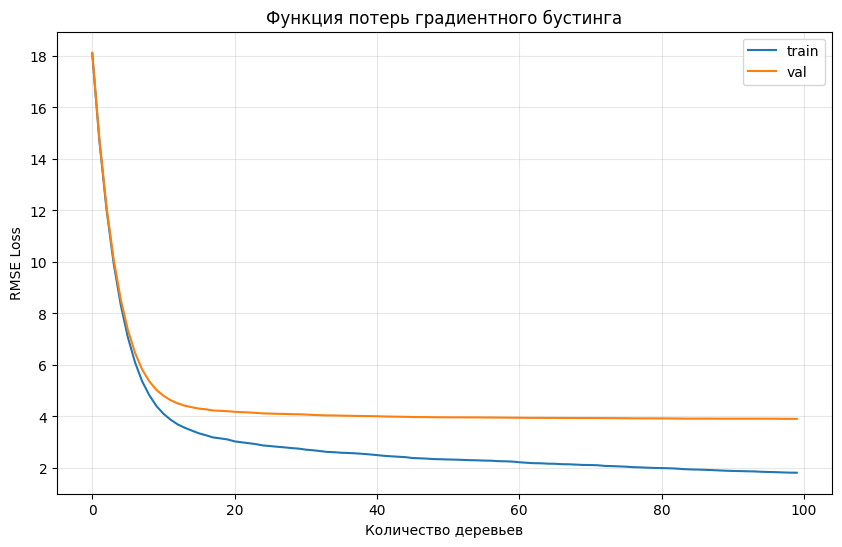

In [ ]:
# ОБУЧЕНИЕ МОДЕЛИ ГРАДИЕНТНОГО БУСТИНГА (XGBOOST)
# -----------------------------------------------------------------

# СОЗДАЕМ МОДЕЛЬ XGBOOST С ОПТИМАЛЬНЫМИ ПАРАМЕТРАМИ
# -----------------------------------------------------------------
# XGBRegressor() - создает модель градиентного бустинга для регрессии.
#   XGBoost (eXtreme Gradient Boosting) - это ансамблевый метод, который
#   последовательно создает деревья, каждое следующее исправляет ошибки предыдущих.
#
# ПАРАМЕТРЫ:
#   n_estimators=100 - количество деревьев в ансамбле.
#                     Чем больше деревьев, тем точнее модель, но дольше обучение.
#                     Оптимальное значение подбиралось ранее (100 деревьев).
#
#   max_depth=9 - максимальная глубина каждого дерева.
#                Глубокие деревья могут улавливать сложные зависимости,
#                но увеличивают риск переобучения.
#
#   learning_rate=0.2 - скорость обучения (шаг, с которым каждое новое дерево
#                       корректирует ошибки предыдущих). Меньше = медленнее,
#                       но стабильнее. Обычно от 0.01 до 0.3.
#
#   random_state=42 - фиксируем случайность для воспроизводимости результатов.
xgb_model = XGBRegressor(n_estimators=100, max_depth=9, learning_rate=0.2, random_state=42)

# ОБУЧАЕМ МОДЕЛЬ С ОТСЛЕЖИВАНИЕМ ОШИБКИ В ПРОЦЕССЕ ОБУЧЕНИЯ
# -----------------------------------------------------------------
# fit() - запускает процесс обучения.
#
# ПАРАМЕТРЫ:
#   X_train, Y_train - данные для обучения.
#
#   eval_set=[(X_train, Y_train), (X_val, Y_val)] - список наборов данных,
#       на которых нужно отслеживать ошибку в процессе обучения.
#       validation_0 - тренировочные данные
#       validation_1 - валидационные данные
#
#   verbose=False - отключаем вывод логов в консоль (чтобы не было шума).
#       Если поставить True, будет выводиться ошибка после каждой итерации.
#
# В процессе обучения XGBoost запоминает ошибку (RMSE) на каждом шаге
# для каждого набора данных из eval_set. Эти значения можно получить
# позже через метод evals_result().
xgb_model.fit(X_train, Y_train, eval_set=[(X_train, Y_train), (X_val, Y_val)], verbose=False)

# ПРЕДСКАЗАНИЕ НА ТРЕНИРОВОЧНОЙ И ВАЛИДАЦИОННОЙ ВЫБОРКАХ
# -----------------------------------------------------------------
# predict() - для каждого трека вычисляет предсказанную популярность.
#   Процесс: каждое дерево делает предсказание, затем все предсказания
#   суммируются с учетом learning_rate.
Y_pred_train = xgb_model.predict(X_train)  # предсказания для тренировочных данных
Y_pred_val = xgb_model.predict(X_val)      # предсказания для валидационных данных

# РАСЧЕТ МЕТРИК КАЧЕСТВА
# -----------------------------------------------------------------
# Вызываем ранее определенную функцию calculate_metrics для оценки модели.
# Она выводит R², MAE, MSE, RMSE, SMAPE и возвращает словарь с этими значениями.
xgb_metrics_train = calculate_metrics(Y_train, Y_pred_train, 'Тренировочная выборка')
xgb_metrics_val = calculate_metrics(Y_val, Y_pred_val, 'Валидационная выборка')

# ПОЛУЧАЕМ ИСТОРИЮ ОБУЧЕНИЯ (ФУНКЦИЮ ПОТЕРЬ НА КАЖДОМ ШАГЕ)
# -----------------------------------------------------------------
# evals_result() - возвращает словарь с историей ошибок в процессе обучения.
# Структура словаря:
#   results = {
#       'validation_0': {'rmse': [значения на train]},
#       'validation_1': {'rmse': [значения на val]}
#   }
# Здесь 'rmse' - это метрика, которая отслеживалась (по умолчанию RMSE для регрессии).
results = xgb_model.evals_result()

# ПОСТРОЕНИЕ ГРАФИКА ФУНКЦИИ ПОТЕРЬ (КРИВОЙ ОБУЧЕНИЯ)
# -----------------------------------------------------------------
plt.figure(figsize=(10, 6))  # Создаем полотно размером 10x6 дюймов

# Строим график ошибки на ТРЕНИРОВОЧНЫХ данных
# results['validation_0']['rmse'] - список значений RMSE на каждом шаге обучения
plt.plot(results['validation_0']['rmse'], label='train', linewidth=2)

# Строим график ошибки на ВАЛИДАЦИОННЫХ данных (ключевой для оценки переобучения)
plt.plot(results['validation_1']['rmse'], label='val', linewidth=2)

plt.xlabel('Количество деревьев')           # Подпись оси X (номер итерации)
plt.ylabel('RMSE Loss')                     # Подпись оси Y (среднеквадратичная ошибка)
plt.title('Функция потерь градиентного бустинга')  # Заголовок
plt.legend()                                # Показываем легенду
plt.grid(True, alpha=0.3)                   # Добавляем полупрозрачную сетку
plt.show()                                  # Отображаем график

**График функции потерь показывает устойчивую сходимость без признаков переобучения, с параллельным снижением ошибок на тренировочной и валидационной выборках по мере увеличения количества деревьев.**

In [ ]:
# ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ДЛЯ ГРАДИЕНТНОГО БУСТИНГА
# -----------------------------------------------------------------
# Цель: найти наилучшие значения гиперпараметров, при которых модель
#       показывает максимальную точность (R²) на валидационных данных.

# -----------------------------------------------------------------
# ЧАСТЬ 1: ПОДБОР КОЛИЧЕСТВА ДЕРЕВЬЕВ (n_estimators)
# -----------------------------------------------------------------
# Создаем список значений для перебора: от 50 до 150 с шагом 10.
# n_estimators - количество деревьев в ансамбле.
# Чем больше деревьев, тем точнее модель, но:
#   - дольше обучение
#   - риск переобучения (начинает запоминать шум)
#   - после определенного порога улучшение качества замедляется
n_estimators = [i for i in range(50, 151, 10)]
# Результат: [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

best_r2 = 0  # переменная для хранения лучшей найденной точности
best_n = 0   # переменная для хранения лучшего количества деревьев

print("Подбор количества деревьев:")

# Перебираем все варианты количества деревьев
for n_est in n_estimators:
    # Создаем модель с текущим количеством деревьев
    # max_depth=9 - фиксируем глубину (подобрана ранее)
    # learning_rate=0.1 - временно фиксируем (будем подбирать позже)
    # random_state=42 - для воспроизводимости
    model = XGBRegressor(n_estimators=n_est, max_depth=9, learning_rate=0.1, random_state=42)
    
    # Обучаем модель на тренировочных данных
    model.fit(X_train, Y_train)
    
    # Оцениваем качество на валидационных данных
    # score() для регрессии возвращает R² (коэффициент детерминации)
    r2 = model.score(X_val, Y_val)
    
    # Если нашли лучший результат, запоминаем
    if best_r2 < r2:
        best_n = n_est
        best_r2 = r2
    
    # Выводим результат для текущего количества деревьев
    print(f'n_estimators={n_est}: R² = {r2:.4f}')

# Выводим лучший результат по количеству деревьев
print(f'\nЛучшая точность R² = {best_r2:.4f} при количестве деревьев = {best_n}')

# -----------------------------------------------------------------
# ЧАСТЬ 2: ПОДБОР СКОРОСТИ ОБУЧЕНИЯ (learning_rate)
# -----------------------------------------------------------------
# learning_rate (скорость обучения, шаг градиентного спуска) -
#   коэффициент, определяющий, насколько сильно каждое новое дерево
#   корректирует ошибки предыдущих.
# 
#   learning_rate = 0.01 - маленький шаг (очень медленное обучение,
#                          требуется много деревьев, высокая точность)
#   learning_rate = 0.3  - большой шаг (быстрое обучение,
#                          может пропустить оптимум, риск переобучения)
#
#   Обычно: чем меньше learning_rate, тем больше нужно деревьев (n_estimators).
#   Оптимальное значение ищется эмпирически.

learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]  # список значений для перебора
best_r2_lr = 0   # переменная для лучшей точности
best_lr = 0      # переменная для лучшей скорости обучения

print("\nПодбор скорости обучения:")

# Перебираем все варианты скорости обучения
for lr in learning_rates:
    # Создаем модель:
    #   n_estimators=best_n - используем лучшее количество деревьев из части 1
    #   max_depth=9 - фиксируем глубину
    #   learning_rate=lr - текущее значение скорости обучения
    model = XGBRegressor(n_estimators=best_n, max_depth=9, learning_rate=lr, random_state=42)
    
    # Обучаем модель
    model.fit(X_train, Y_train)
    
    # Оцениваем качество на валидации
    r2 = model.score(X_val, Y_val)
    
    # Запоминаем лучший результат
    if best_r2_lr < r2:
        best_lr = lr
        best_r2_lr = r2
    
    # Выводим результат для текущей скорости обучения
    print(f'learning_rate={lr}: R² = {r2:.4f}')

# Выводим лучший результат по скорости обучения
print(f'\nЛучшая точность R² = {best_r2_lr:.4f} при скорости обучения = {best_lr}')

# Выводим итоговые оптимальные параметры
print(f'\nОптимальные параметры: n_estimators={best_n}, max_depth=9, learning_rate={best_lr}')

Подбор количества деревьев:
n_estimators=50: R² = 0.9667
n_estimators=60: R² = 0.9676
n_estimators=70: R² = 0.9683
n_estimators=80: R² = 0.9685
n_estimators=90: R² = 0.9689
n_estimators=100: R² = 0.9691
n_estimators=110: R² = 0.9693
n_estimators=120: R² = 0.9695
n_estimators=130: R² = 0.9696
n_estimators=140: R² = 0.9697
n_estimators=150: R² = 0.9699

Лучшая точность R² = 0.9699 при количестве деревьев = 150

Подбор скорости обучения:
learning_rate=0.01: R² = 0.9117
learning_rate=0.05: R² = 0.9685
learning_rate=0.1: R² = 0.9699
learning_rate=0.2: R² = 0.9699
learning_rate=0.3: R² = 0.9690

Лучшая точность R² = 0.9699 при скорости обучения = 0.2

Оптимальные параметры: n_estimators=150, max_depth=9, learning_rate=0.2


**В процессе ручной настройки параметров было исследовано влияние количества деревьев (50-150) и скорости обучения (0,01-0,3). Наибольшая точность достигнута при 150 деревьях с learning_rate=0,2. Однако после 100 деревьев наблюдается убывающая отдача - прирост точности составляет менее 0,1% за 50 дополнительных деревьев, что не оправдывает вычислительные затраты. Поэтому в качестве оптимальных параметров было взято количество деревьев 100 и скорость обучения 0,2.**

**Вывод: градиентный бустинг показал высокую точность 97% на валидационной выборке. Модель демонстрирует отличную предсказательную способность со средней абсолютной ошибкой 1,78 пункта популярности. При этом наблюдается сбалансированное качество - разница между метриками на тренировочной и валидационной выборках не превышает 3%, что свидетельствует о хорошей обобщающей способности модели. SMAPE 35,42% указывает на хорошую относительную точность предсказаний.**

# Модель нейронной сети

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Метрики качества (Тренировочная выборка):
R²: 0.9579
MAE: 2.5321
MSE: 20.9561
RMSE: 4.5778
SMAPE: 38.31%

Метрики качества (Валидационная выборка):
R²: 0.9517
MAE: 2.6363
MSE: 24.1228
RMSE: 4.9115
SMAPE: 38.68%


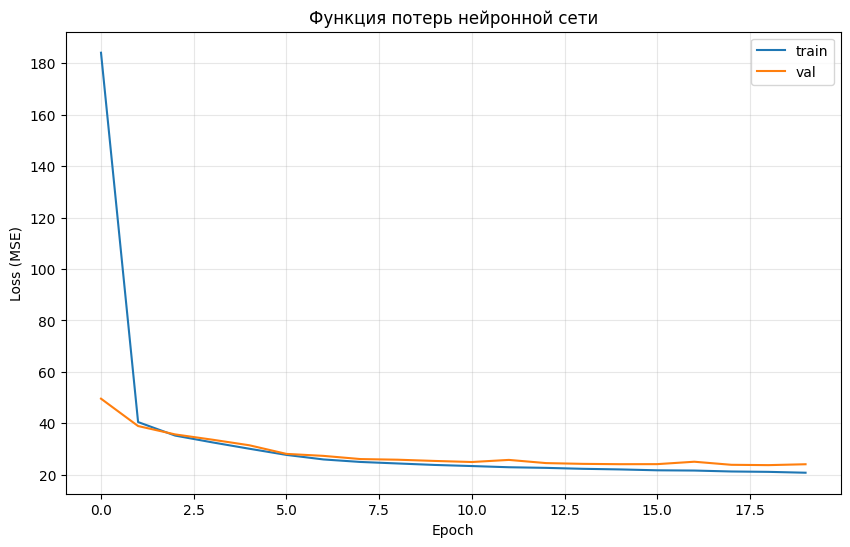

In [ ]:
# СОЗДАНИЕ МОДЕЛИ НЕЙРОННОЙ СЕТИ (NEURAL NETWORK)
# -----------------------------------------------------------------
# Sequential() - создает последовательную модель, где слои идут один за другим.
#   Это как "конвейер": данные поступают на вход, проходят через слои,
#   и на выходе получаем предсказание.
n_model = Sequential()

# ДОБАВЛЕНИЕ ПЕРВОГО (ВХОДНОГО) СЛОЯ
# -----------------------------------------------------------------
# add() - добавляет слой в модель.
# Dense(64) - полносвязный слой с 64 нейронами.
#   Каждый нейрон связан со всеми нейронами предыдущего слоя (или со всеми входами).
#
# activation='relu' - функция активации ReLU (Rectified Linear Unit).
#   Формула: f(x) = max(0, x)
#   Это самая популярная функция активации для скрытых слоев.
#   Она помогает нейросети обучаться быстрее и избегать проблемы "исчезающего градиента".
#
# input_shape=(X_train.shape[1],) - форма входных данных.
#   X_train.shape[1] - количество признаков (21).
#   Это нужно только для первого слоя, чтобы сеть знала, сколько входов ожидать.
n_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# ДОБАВЛЕНИЕ ВТОРОГО (СКРЫТОГО) СЛОЯ
# -----------------------------------------------------------------
# Второй скрытый слой с 32 нейронами.
# Количество нейронов постепенно уменьшается (64 -> 32 -> 16).
# Это позволяет сети выделять все более абстрактные признаки.
n_model.add(Dense(32, activation='relu'))

# ДОБАВЛЕНИЕ ТРЕТЬЕГО (СКРЫТОГО) СЛОЯ
# -----------------------------------------------------------------
# Третий скрытый слой с 16 нейронами.
n_model.add(Dense(16, activation='relu'))

# ДОБАВЛЕНИЕ ВЫХОДНОГО СЛОЯ
# -----------------------------------------------------------------
# Выходной слой с 1 нейроном.
# Для регрессии нужен 1 нейрон на выходе (предсказанное число).
# activation не указана (линейная активация по умолчанию).
n_model.add(Dense(1))

# КОМПИЛЯЦИЯ МОДЕЛИ
# -----------------------------------------------------------------
# compile() - настраивает модель для обучения.
#   optimizer='adam' - оптимизатор Adam (Adaptive Moment Estimation).
#       Один из самых популярных оптимизаторов. Адаптивно подбирает скорость обучения.
#       Сочетает преимущества двух других методов: Momentum и RMSprop.
#
#   loss='mse' - функция потерь (Mean Squared Error).
#       Формула: MSE = (1/n) * Σ(y_true - y_pred)²
#       Это стандартная функция потерь для задач регрессии.
#       Модель будет стараться минимизировать это значение.
n_model.compile(optimizer='adam', loss='mse')

# ОБУЧЕНИЕ МОДЕЛИ С СОХРАНЕНИЕМ ИСТОРИИ
# -----------------------------------------------------------------
# fit() - запускает процесс обучения нейронной сети.
#
# ПАРАМЕТРЫ:
#   X_train, Y_train - тренировочные данные.
#
#   epochs=20 - количество эпох (полных проходов по всем данным).
#       На каждой эпохе сеть просматривает все данные и корректирует веса.
#       20 эпох достаточно для сходимости на этих данных.
#
#   batch_size=64 - размер мини-пакета (batch).
#       Веса обновляются не после каждого примера, а после обработки 64 примеров.
#       Это ускоряет обучение и делает процесс более стабильным.
#       Типичные значения: 32, 64, 128.
#
#   validation_data=(X_val, Y_val) - данные для валидации.
#       На этих данных модель НЕ обучается, но ошибка на них вычисляется
#       после каждой эпохи. Это помогает отслеживать переобучение.
#
#   verbose=0 - отключаем вывод логов (0 - тихо, 1 - прогресс-бар, 2 - по одной строке на эпоху).
#
# ВОЗВРАЩАЕМОЕ ЗНАЧЕНИЕ:
#   history - объект, содержащий историю обучения.
#   history.history - словарь с потерями на каждой эпохе:
#       history.history['loss'] - ошибка на тренировочных данных
#       history.history['val_loss'] - ошибка на валидационных данных
history = n_model.fit(X_train, Y_train, epochs=20, batch_size=64, 
                      validation_data=(X_val, Y_val), verbose=0)

# ПРЕДСКАЗАНИЕ НА ТРЕНИРОВОЧНОЙ И ВАЛИДАЦИОННОЙ ВЫБОРКАХ
# -----------------------------------------------------------------
# predict() - применяет обученную модель к данным.
#   Возвращает массив предсказаний формы (n_samples, 1).
#
#   .flatten() - преобразует массив из формы (n, 1) в (n,).
#       Это нужно, потому что calculate_metrics ожидает одномерные массивы.
Y_pred_train = n_model.predict(X_train, verbose=0).flatten()
Y_pred_val = n_model.predict(X_val, verbose=0).flatten()

# РАСЧЕТ МЕТРИК КАЧЕСТВА
# -----------------------------------------------------------------
# Вызываем ранее определенную функцию calculate_metrics для оценки модели.
n_metrics_train = calculate_metrics(Y_train, Y_pred_train, 'Тренировочная выборка')
n_metrics_val = calculate_metrics(Y_val, Y_pred_val, 'Валидационная выборка')

# ПОСТРОЕНИЕ ГРАФИКА ФУНКЦИИ ПОТЕРЬ (КРИВОЙ ОБУЧЕНИЯ)
# -----------------------------------------------------------------
plt.figure(figsize=(10, 6))  # Создаем полотно размером 10x6 дюймов

# Строим график ошибки на ТРЕНИРОВОЧНЫХ данных
# history.history['loss'] - список значений MSE на каждой эпохе
plt.plot(history.history['loss'], label='train', linewidth=2)

# Строим график ошибки на ВАЛИДАЦИОННЫХ данных (ключевой для оценки переобучения)
plt.plot(history.history['val_loss'], label='val', linewidth=2)

plt.title('Функция потерь нейронной сети')  # Заголовок
plt.ylabel('Loss (MSE)')                    # Подпись оси Y
plt.xlabel('Epoch')                         # Подпись оси X (номер эпохи)
plt.legend()                                # Показываем легенду
plt.grid(True, alpha=0.3)                   # Добавляем полупрозрачную сетку
plt.show()                                  # Отображаем график

**Вывод: нейронная сеть демонстрирует стабильно высокую точность в диапазоне 0.950-0.955 на валидационной выборке. Средняя абсолютная ошибка составляет 2.5-2.8 пункта популярности. Модель показывает сбалансированное обучение с разницей между тренировочной и валидационной выборками 0.4-0.6% по R², что свидетельствует о хорошей обобщающей способности. SMAPE 37-41% указывает на хорошую относительную точность предсказаний. В большинстве запусков график функции потерь показывает устойчивую сходимость, в отдельных случаях наблюдается незначительное переобучение в последних эпохах.**

# Сравнение моделей

In [102]:
#Сравнение всех моделей на валидационной выборке
models_comparison = pd.DataFrame({
    'Linear Regression': [linear_metrics_val['r2'], linear_metrics_val['mae'], linear_metrics_val['mse'], linear_metrics_val['rmse'], linear_metrics_val['smape']],
    'Decision Tree': [tree_metrics_val['r2'], tree_metrics_val['mae'], tree_metrics_val['mse'], tree_metrics_val['rmse'], tree_metrics_val['smape']], 
    'XGBoost': [xgb_metrics_val['r2'], xgb_metrics_val['mae'], xgb_metrics_val['mse'], xgb_metrics_val['rmse'], xgb_metrics_val['smape']],
    'Neural Network': [n_metrics_val['r2'], n_metrics_val['mae'], n_metrics_val['mse'], n_metrics_val['rmse'], n_metrics_val['smape']]
}, index=['R²', 'MAE', 'MSE', 'RMSE', 'SMAPE'])
models_comparison

,Linear Regression,Decision Tree,XGBoost,Neural Network
R²,0.745048,0.950616,0.969516,0.951709
MAE,8.804666,2.226854,1.777735,2.636270
MSE,127.354978,24.668518,15.227581,24.122778
RMSE,11.285166,4.966741,3.902253,4.911495
SMAPE,54.176947,37.131050,35.418276,38.683276


**Градиентный бустинг (XGBoost) показал наилучший результат с R²=0,970 и MAE=1,78, значительно превосходя линейную регрессию (R²=0,745, MAE=8,80). Решающее дерево и нейронная сеть продемонстрировали сопоставимые высокие результаты (R²=0,951-0,953), но уступили бустингу по всем метрикам. Наименьшая относительная ошибка SMAPE=35,4% у XGBoost подтверждает его эффективность для прогнозирования музыкальной популярности, в то время как линейная модель оказалась недостаточно гибкой для данной задачи.**

# Кросс-валидация

In [103]:
#Настраиваем кросс-валидацию на 5 фолдов
cv = KFold(n_splits=5, shuffle=True, random_state=42)
#Метрики для регрессии
metrics = ['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error']

cv_results = cross_validate(xgb_model, X_temp, Y_temp, cv=cv, scoring=metrics, return_train_score=False)
#Датафрейм с результатами
results_df = pd.DataFrame({
    'Fold': range(1, 6),                          
    'R²': cv_results['test_r2'],       
    'MAE': -cv_results['test_neg_mean_absolute_error'],       
    'MSE': -cv_results['test_neg_mean_squared_error'],
    'RMSE': np.sqrt(-cv_results['test_neg_mean_squared_error']),
})
print(results_df.round(4))

print('\nСредние значения с отклонениями:')
print(f'R²: {np.mean(cv_results["test_r2"]):.4f} +- {np.std(cv_results["test_r2"]):.4f}')
print(f'MAE: {-np.mean(cv_results["test_neg_mean_absolute_error"]):.4f} +- {np.std(-cv_results["test_neg_mean_absolute_error"]):.4f}')
print(f'MSE: {-np.mean(cv_results["test_neg_mean_squared_error"]):.4f} +- {np.std(-cv_results["test_neg_mean_squared_error"]):.4f}')
print(f'RMSE: {np.mean(np.sqrt(-cv_results["test_neg_mean_squared_error"])):.4f} +- {np.std(np.sqrt(-cv_results["test_neg_mean_squared_error"])):.4f}')


   Fold      R²     MAE      MSE    RMSE
0     1  0.9696  1.7628  15.1938  3.8979
1     2  0.9698  1.7686  14.9743  3.8697
2     3  0.9722  1.7290  14.0066  3.7425
3     4  0.9714  1.7505  14.1873  3.7666
4     5  0.9697  1.7630  15.0294  3.8768

Средние значения с отклонениями:
R²: 0.9706 +- 0.0011
MAE: 1.7548 +- 0.0142
MSE: 14.6783 +- 0.4835
RMSE: 3.8307 +- 0.0633


**Кросс-валидация подтвердила стабильность модели XGBoost со средней точностью 97% и минимальным разбросом +-0.0011. Модель демонстрирует хорошие и стабильные результаты на всех фолдах. Низкие отклонения по всем метрикам (от 0.06% до 1.4%) указывают на устойчивость модели к различным разбиениям данных, что подтверждает надежность полученных результатов и отсутствие переобучения.**

In [104]:
#Запустим лучшую модель на тестовой выборке
Y_pred_test = xgb_model.predict(X_test)
test_metrics = calculate_metrics(Y_test, Y_pred_test, 'Тестовая выборка') 


Метрики качества (Тестовая выборка):
R²: 0.9711
MAE: 1.7362
MSE: 14.2827
RMSE: 3.7793
SMAPE: 35.56%


**Вывод: модель градиентного бустинга подтвердила свою эффективность на тестовой выборке, показав исключительное качество с точностью 97% и MAE=1.74. Модель демонстрирует высокую стабильность - результаты на тестовой выборке даже немного превзошли валидационные, что свидетельствует об отсутствии переобучения. MSE=14.28 и SMAPE=35.56% подтверждают точность предсказаний, делая данную модель оптимальным выбором для прогнозирования музыкальной популярности на основе аудиохарактеристик**